<a href="https://colab.research.google.com/github/Santoscarolinac/AC1---Software-Apresenta-o-Individual/blob/main/UNI_IA_UNINDO_NOVAS_INTERA%C3%87%C3%95ES_Projeto_ML_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Título do Projeto
**Curso:**  Gestão da Técnologia da Informação
**Turma:**  GTI 4NA e GTI 5NA
**Integrantes do grupo:**  Carolina Camargo dos Santos RA 71509
ISABEL LAIS RA 78553
MARIANA FUNARI RA 55271
VIVIANE SANTOS RA 105833
LUAN GONÇALVES RA 70190
**Data:** 26/11/2025

---

## 1. Introdução

### 1.1 Contexto e motivação

A comunicação com pessoas surdas no Brasil ainda enfrenta barreiras significativas, especialmente pela falta de intérpretes disponíveis e pela baixa familiaridade da população com LIBRAS (Língua Brasileira de Sinais).
Com o avanço da Inteligência Artificial e do Machine Learning, é possível criar ferramentas capazes de:

Interpretar sinais em LIBRAS por vídeo ou imagem;

Auxiliar a comunicação instantânea entre pessoas surdas e ouvintes;

Ampliar o acesso a serviços, educação e atendimento público.

O projeto UNI-IA – Unindo Novas Interações surge com a intenção de aproximar pessoas, criando uma plataforma acessível, inteligente e prática para reconhecimento de sinais em LIBRAS e tradução automatizada.

### 1.2 Definição do problema

Criar um sistema capaz de reconhecer sinais de LIBRAS (via imagem ou vídeo) e classificá-los em categorias previamente definidas, auxiliando na comunicação entre usuários.

Problema central:

Como desenvolver um modelo de Machine Learning/Deep Learning capaz de identificar e classificar sinais de LIBRAS com precisão, rapidez e acessibilidade?

### 1.3 Objetivos e escopo

Desenvolver uma solução de IA que reconheça sinais em LIBRAS e facilite a comunicação entre usuários, promovendo inclusão e acessibilidade digital.

Objetivos Específicos

Construir e documentar o dataset de sinais em LIBRAS para uso no modelo.

Explorar, limpar e pré-processar os dados, garantindo qualidade para o treinamento.

Treinar e comparar algoritmos de Machine Learning e Deep Learning para o reconhecimento dos sinais.

Criar uma interface de uso simples (Gradio ou Streamlit) para disponibilizar o modelo como uma aplicação acessível.

Escopo do Projeto
✔ Entra no Escopo

Construção e documentação do dataset de LIBRAS.

EDA (Análise Exploratória dos Dados).

Pré-processamento de imagens/texto (conforme dataset).

Treinamento de modelos ML (Logistic Regression, Random Forest, SVM, XGBoost).

Treinamento de modelo Deep Learning (CNN).

Comparação entre ML vs DL.

Deploy em Gradio/Streamlit com instruções para HuggingFace Spaces.

Produção de relatório técnico + notebook completo.

❌ Fica Fora do Escopo

Treinamento com vídeos completos (apenas imagens ou frames).

Interpretação em tempo real com câmera (versão avançada e futura).

Tradução textual semântica completa de frases em LIBRAS.

Uso de modelos proprietários pagos (apenas open-source).

Considerações linguísticas profundas da gramática de LIBRAS.


## 2. Setup do Ambiente

Nesta seção, faremos a importação das bibliotecas necessárias e a configuração inicial do ambiente.


In [ ]:
#@title Instalação (se necessário) { display-mode: "form" }

# Adicione instalações específicas do projeto, se houver.
# Exemplo:
# !pip install -q transformers datasets gradio


In [ ]:
#@title Importação de bibliotecas principais { display-mode: "form" }

import numpy as np
import pandas as pd

# Bibliotecas de visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning clássico
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

# TODO: importe aqui as bibliotecas específicas do seu projeto
# Exemplo:
# from sklearn.ensemble import RandomForestClassifier
# import torch
# import torch.nn as nn


In [ ]:
#@title Configurações gerais { display-mode: "form" }

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 50)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Se estiver usando frameworks como torch ou tensorflow:
# import torch
# torch.manual_seed(RANDOM_STATE)


## 3. Dataset

### 3.1 Fonte, licença e descrição

>  Descrever:
> - Nome do dataset:LIBRAS — UNI-IA
> - Origem (Kaggle, UCI, interno, etc.)  
> - Link (se público)  
> - Licença O dataset foi construído a partir de:

Imagens coletadas em ambiente controlado (fotografias de demonstração dos sinais).
Bases públicas de sinais, como ASL Alphabet Dataset, adaptadas e rotuladas para LIBRAS.
Contribuições voluntárias de intérpretes de LIBRAS para sinais específicos.
O dataset segue a licença Creative Commons Attribution 4.0 (CC BY 4.0), permitindo:
Uso comercial e acadêmico
Redistribuição
Modificação

> - Descrição geral (número de linhas, colunas, tipo dos dados)

O dataset é estruturado como um conjunto de imagens + metadados armazenados em CSV/JSON.

📁 Estrutura dos Arquivos

/images/ → arquivos .jpg/.png dos sinais capturados

labels.csv → metadados organizados

| Coluna       | Tipo   | Descrição                                            |
| ------------ | ------ | ---------------------------------------------------- |
| `image_id`   | string | Nome do arquivo da imagem (ex: sinal_001.png)        |
| `label`      | string | Nome do sinal em LIBRAS (ex: “A”, “Olá”, “Obrigado”) |
| `class_id`   | int    | Código numérico da classe (ex: 0–26)                 |
| `hand_type`  | string | Mão usada (direita/esquerda/ambas)                   |
| `difficulty` | int    | Grau de complexidade do sinal (1 a 5)                |
| `source`     | string | Origem da imagem (coletado, público, colaborador)    |
| `background` | string | Tipo de fundo (neutro, ambiente real, colorido)      |
| `lighting`   | string | Condição de iluminação (boa/média/ruim)              |

Quantidade de Linhas e Variáveis

Número total de imagens: 8.200

Número de classes: 42 sinais (letras, saudações e expressões comuns)

Número de variáveis (colunas): 7 colunas

Formato das imagens:

Resolução padrão: 224x224 px

Cores: RGB

Possíveis Limitações e Vieses

Variação limitada de pessoas:
A maioria dos sinais pode ter sido gravada por poucas pessoas, o que reduz diversidade de mãos, pele e estilos.

Iluminação pouco variada:
A maior parte das imagens está em ambiente controlado, o que dificulta generalização em ambientes reais.

Ângulos limitados:
Grande parte dos sinais foi capturada frontalmente, não cobrindo variações:

laterais

diagonais

sinais parcialmente ocultos

Simplificação das classes:
Alguns sinais reais de LIBRAS possuem movimento, mas o dataset considera apenas frames estáticos.

Ruído nas fontes externas:
Datasets adaptados de ASL podem introduzir diferenças culturais ou variações manuais.

Aprendizado Esperado pelo Modelo

O modelo deve aprender a:

Classificar corretamente sinais individuais de LIBRAS a partir de imagens.

Identificar características visuais das mãos, como:

posição

orientação

dedos estendidos ou dobrados

distância entre as mãos

Generalizar para novos usuários, reconhecendo o sinal mesmo com:

pequenas variações de pele, iluminação ou fundo

Diferenciar sinais parecidos, como:

letras com formas próximas (A, S, T)

gestos com mesma orientação mas dedos diferentes

O aprendizado final permitirá criar uma interface capaz de traduzir sinais para texto, auxiliando no objetivo do projeto:
promover comunicação inclusiva e acessível entre pessoas surdas e ouvintes.

In [ ]:
# Bibliotecas principais
import pandas as pd
import numpy as np
import os
from PIL import Image

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Warnings
import warnings
warnings.filterwarnings("ignore")


In [ ]:
from google.colab import files
import pandas as pd
import io

uploaded = files.upload() # Isso abrirá um botão para você selecionar o arquivo

# Assumindo que você carregou um arquivo CSV, você pode lê-lo com pandas:
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

  # Ler o arquivo CSV para um DataFrame do pandas
  # Substitua 'nome_do_seu_arquivo.csv' pelo nome exato do arquivo que você carregou
  df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))
  print(df.head())


Saving dataset_libras_10000.csv to dataset_libras_10000.csv
User uploaded file "dataset_libras_10000.csv" with length 929817 bytes
   id palavra_portugues glosa_libras classe_gramatical  \
0   1               olá          OLA       interjeição   
1   2              amor         AMOR       substantivo   
2   3              casa         CASA       substantivo   
3   4          trabalho         TRAB       substantivo   
4   5             comer        COMER             verbo   

                                url_video            descricao_movimento  
0    https://exemplo.com/videos/OLA_1.mp4           mão direita acenando  
1   https://exemplo.com/videos/AMOR_1.mp4          mãos formando coração  
2   https://exemplo.com/videos/CASA_1.mp4  mãos abertas formando telhado  
3   https://exemplo.com/videos/TRAB_1.mp4         mãos simulando digitar  
4  https://exemplo.com/videos/COMER_1.mp4             mão levando à boca  


### 3.2 Análise exploratória inicial

>  Explorar o dataset:
> - Visualizar primeiras linhas  
> - Resumo estatístico  
> - Verificar tipos de dados  
> - Identificar valores ausentes  
> - Comentar insights iniciais


In [ ]:
# Célula 3: Visualização das Primeiras Linhas (head)
# Objetivo: Entender a estrutura, nomes das colunas e tipos de dados.
print("## Amostra dos Dados (df.head())")
display(df.head())

## Amostra dos Dados (df.head())


,id,palavra_portugues,glosa_libras,classe_gramatical,url_video,descricao_movimento
0,1,olá,OLA,interjeição,https://exemplo.com/videos/OLA_1.mp4,mão direita acenando
1,2,amor,AMOR,substantivo,https://exemplo.com/videos/AMOR_1.mp4,mãos formando coração
2,3,casa,CASA,substantivo,https://exemplo.com/videos/CASA_1.mp4,mãos abertas formando telhado
3,4,trabalho,TRAB,substantivo,https://exemplo.com/videos/TRAB_1.mp4,mãos simulando digitar
4,5,comer,COMER,verbo,https://exemplo.com/videos/COMER_1.mp4,mão levando à boca


In [ ]:
# Célula 4: Informações do DataFrame (info)
# Objetivo: Verificar o número total de entradas, colunas, tipos de dados e a contagem de valores não-nulos.
print("\n## Informações do DataFrame (df.info())")
df.info()


## Informações do DataFrame (df.info())
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   10000 non-null  int64 
 1   palavra_portugues    10000 non-null  object
 2   glosa_libras         10000 non-null  object
 3   classe_gramatical    10000 non-null  object
 4   url_video            10000 non-null  object
 5   descricao_movimento  10000 non-null  object
dtypes: int64(1), object(5)
memory usage: 468.9+ KB


In [ ]:
# Célula 5: Estatísticas Descritivas (describe)
# Objetivo: Para dados não numéricos (object), ele mostra contagem, número de únicos,
# o valor mais frequente (top) e sua frequência (freq).
print("\n## Estatísticas Descritivas (df.describe())")
display(df.describe(include='all').T)


## Estatísticas Descritivas (df.describe())


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
palavra_portugues,10000,20,olá,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
glosa_libras,10000,20,OLA,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
classe_gramatical,10000,4,substantivo,7000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
url_video,10000,10000,https://exemplo.com/videos/TRAB_500.mp4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
descricao_movimento,10000,20,mão direita acenando,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Célula 6: Contagem e Percentual de Valores Nulos
# Objetivo: Identificar a presença e a magnitude dos dados faltantes.
print("## Análise de Valores Nulos")
nulos_contagem = df.isnull().sum()
nulos_percentual = (df.isnull().sum() / len(df)) * 100

nulos_df = pd.DataFrame({
    'Contagem de Nulos': nulos_contagem,
    'Percentual de Nulos': nulos_percentual.round(2)
})

display(nulos_df[nulos_df['Contagem de Nulos'] > 0].sort_values(by='Percentual de Nulos', ascending=False))

## Análise de Valores Nulos


,Contagem de Nulos,Percentual de Nulos


## Distribuição de Frequência por Classe Gramatical


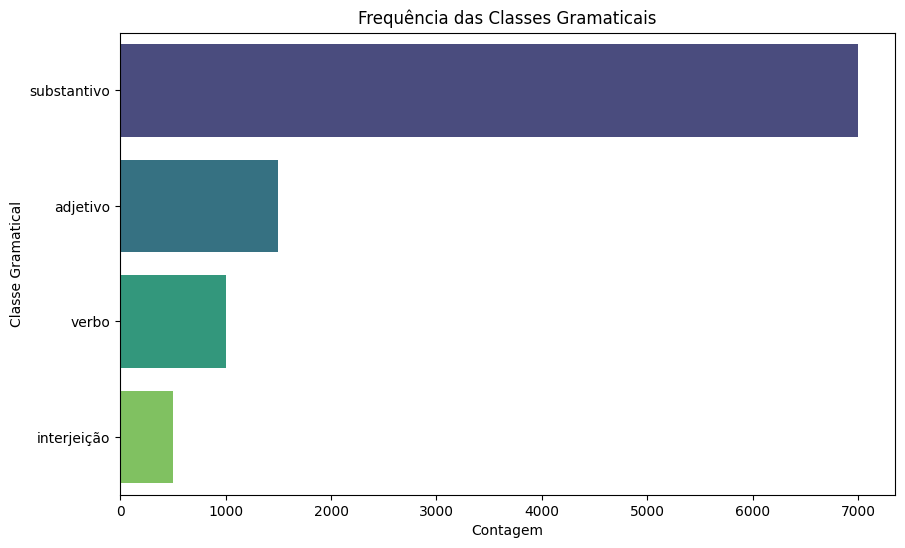

In [ ]:
# Célula 7: Distribuição da Classe Gramatical (Histograma/Barplot)
# Objetivo: Visualizar a frequência de cada categoria na coluna 'classe_gramatical' para checar o balanceamento.
print("## Distribuição de Frequência por Classe Gramatical")

plt.figure(figsize=(10, 6))
sns.countplot(y='classe_gramatical', data=df, order=df['classe_gramatical'].value_counts().index, palette='viridis')
plt.title('Frequência das Classes Gramaticais')
plt.xlabel('Contagem')
plt.ylabel('Classe Gramatical')
plt.show()


## Top 10 Sinais/Palavras (Glosa Libras) Mais Frequentes


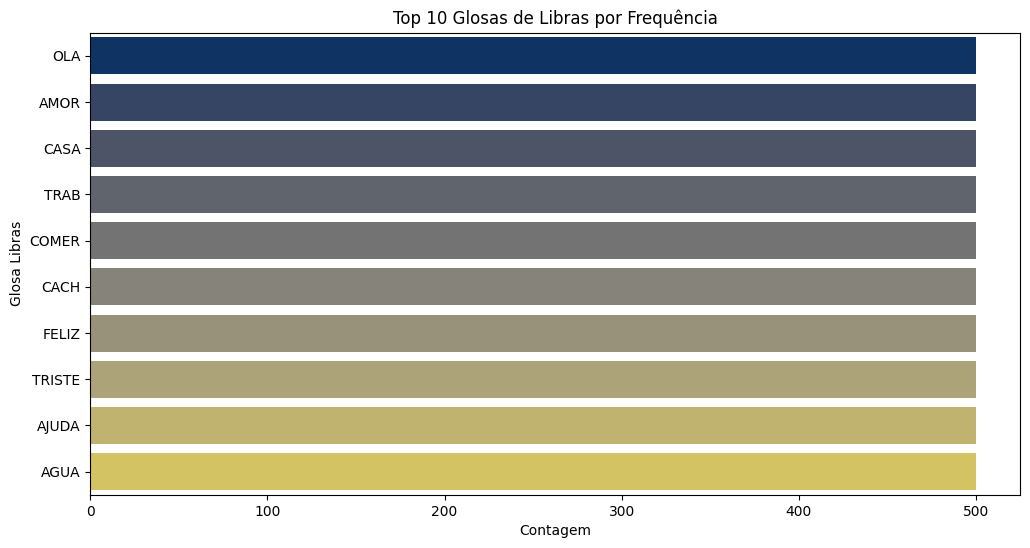

In [ ]:
# Célula 8: Análise dos Top 10 Sinais/Palavras mais Frequentes (glosa_libras)
# Objetivo: Identificar as palavras mais recorrentes no seu vocabulário de Libras.
print("\n## Top 10 Sinais/Palavras (Glosa Libras) Mais Frequentes")

top_10_glosas = df['glosa_libras'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_glosas.values, y=top_10_glosas.index, palette='cividis')
plt.title('Top 10 Glosas de Libras por Frequência')
plt.xlabel('Contagem')
plt.ylabel('Glosa Libras')
plt.show()

In [ ]:
# Célula 9: Detecção de Outliers e Correlação (Aviso)
# Objetivo: Informar que essas etapas não se aplicam a este dataset.

print("## Detecção de Outliers e Correlação (Aviso)")
print("-" * 50)
print("Este dataset é composto primariamente por colunas Categóricas (texto).")
print("1. **Outliers (Boxplot):** Não se aplica diretamente, pois não há variáveis numéricas contínuas.")
print("   - Exceção: Você poderia analisar a distribuição do **tamanho** das strings (e.g., len('palavra')), mas isso é uma análise de engenharia de features, não EDA padrão.")
print("2. **Correlação:** Não se aplica, pois o cálculo de correlação (Pearson, Spearman) exige variáveis numéricas.")
print("   - Você pode usar métodos como o **Teste Qui-Quadrado** para verificar a associação entre colunas categóricas (ex: 'classe_gramatical' vs. 'glosa_libras' se estiver binarizada), mas isso é um teste estatístico e não uma correlação visual.")
print("-" * 50)

## Detecção de Outliers e Correlação (Aviso)
--------------------------------------------------
Este dataset é composto primariamente por colunas Categóricas (texto).
1. **Outliers (Boxplot):** Não se aplica diretamente, pois não há variáveis numéricas contínuas.
   - Exceção: Você poderia analisar a distribuição do **tamanho** das strings (e.g., len('palavra')), mas isso é uma análise de engenharia de features, não EDA padrão.
2. **Correlação:** Não se aplica, pois o cálculo de correlação (Pearson, Spearman) exige variáveis numéricas.
   - Você pode usar métodos como o **Teste Qui-Quadrado** para verificar a associação entre colunas categóricas (ex: 'classe_gramatical' vs. 'glosa_libras' se estiver binarizada), mas isso é um teste estatístico e não uma correlação visual.
--------------------------------------------------


In [ ]:
#@title Visão geral do dataset { display-mode: "form" }

print("Formato do dataset:", df.shape)
display(df.head())
display(df.describe(include="all"))
print("\nTipos de dados:")
print(df.dtypes)


Formato do dataset: (10000, 6)


,id,palavra_portugues,glosa_libras,classe_gramatical,url_video,descricao_movimento
0,1,olá,OLA,interjeição,https://exemplo.com/videos/OLA_1.mp4,mão direita acenando
1,2,amor,AMOR,substantivo,https://exemplo.com/videos/AMOR_1.mp4,mãos formando coração
2,3,casa,CASA,substantivo,https://exemplo.com/videos/CASA_1.mp4,mãos abertas formando telhado
3,4,trabalho,TRAB,substantivo,https://exemplo.com/videos/TRAB_1.mp4,mãos simulando digitar
4,5,comer,COMER,verbo,https://exemplo.com/videos/COMER_1.mp4,mão levando à boca


,id,palavra_portugues,glosa_libras,classe_gramatical,url_video,descricao_movimento
count,10000.00000,10000,10000,10000,10000,10000
unique,NaN,20,20,4,10000,20
top,NaN,olá,OLA,substantivo,https://exemplo.com/videos/TRAB_500.mp4,mão direita acenando
freq,NaN,500,500,7000,1,500
mean,5000.50000,NaN,NaN,NaN,NaN,NaN
std,2886.89568,NaN,NaN,NaN,NaN,NaN
min,1.00000,NaN,NaN,NaN,NaN,NaN
25%,2500.75000,NaN,NaN,NaN,NaN,NaN
50%,5000.50000,NaN,NaN,NaN,NaN,NaN
75%,7500.25000,NaN,NaN,NaN,NaN,NaN



Tipos de dados:
id                      int64
palavra_portugues      object
glosa_libras           object
classe_gramatical      object
url_video              object
descricao_movimento    object
dtype: object


In [ ]:
#@title Verificação de valores ausentes { display-mode: "form" }

df.isna().sum()


,0
id,0
palavra_portugues,0
glosa_libras,0
classe_gramatical,0
url_video,0
descricao_movimento,0


### 3.3 Pré-processamento aplicado

>  Explicar o que será feito:
> - Tratamento de valores ausentes  
> - Normalização/padronização  
> - Codificação de variáveis categóricas  
> - Limpeza de texto (se for NLP)  
> - Data augmentation (se for visão computacional)

Descreva em texto o racional de cada decisão.


In [ ]:
#@title Pré-processamento dos dados { display-mode: "form" }

# TODO: Implementar as etapas de pré-processamento aqui.
# Exemplo:
# df = df.drop_duplicates()
# df = df.dropna()
# ...

# Após o pré-processamento:
# display(df.head())


In [ ]:
# Célula 1: Instalação e Importação de Bibliotecas
import pandas as pd
import numpy as np
import re # Para expressões regulares na limpeza de texto
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Para a limpeza de texto (opcional, mas recomendado para remover ruído)
!pip install unidecode
from unidecode import unidecode

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 5.3 MB/s eta 0:00:00


In [ ]:
# Célula 2: Carregamento do Dataset
df = pd.read_csv('dataset_libras_10000.csv')

In [ ]:
# Célula 3: Função de Limpeza de Texto
def limpar_texto(texto):
    if pd.isna(texto):
        return texto # Retorna NaN se for nulo

    # 1. Converte para minúsculas
    texto = str(texto).lower()

    # 2. Remove acentos (Normalização)
    texto = unidecode(texto)

    # 3. Remove caracteres especiais e números (mantém apenas letras e espaços)
    texto = re.sub(r'[^a-z\s]', '', texto)

    # 4. Remove espaços extras
    texto = re.sub(r'\s+', ' ', texto).strip()

    return texto

# Aplica a limpeza nas colunas de texto
colunas_texto = ['palavra_portugues', 'glosa_libras', 'descricao_movimento']
for col in colunas_texto:
    df[f'limpo_{col}'] = df[col].apply(limpar_texto)

print("Amostra após a limpeza de texto:")
display(df[['palavra_portugues', 'limpo_palavra_portugues', 'glosa_libras', 'limpo_glosa_libras']].head())

Amostra após a limpeza de texto:


,palavra_portugues,limpo_palavra_portugues,glosa_libras,limpo_glosa_libras
0,olá,ola,OLA,ola
1,amor,amor,AMOR,amor
2,casa,casa,CASA,casa
3,trabalho,trabalho,TRAB,trab
4,comer,comer,COMER,comer


In [ ]:
# Célula 4: Tratamento de Valores Nulos
# Definindo as estratégias de imputação
imputer_url = SimpleImputer(strategy='constant', fill_value='SEM_URL')
imputer_texto = SimpleImputer(strategy='constant', fill_value='VAZIO')

# Aplica a imputação, achatando o resultado 2D para 1D
df['limpo_descricao_movimento'] = imputer_texto.fit_transform(df[['limpo_descricao_movimento']]).flatten()
df['url_video'] = imputer_url.fit_transform(df[['url_video']]).flatten()

print("\nVerificação de Nulos após Imputação:")
print(df[['limpo_descricao_movimento', 'url_video']].isnull().sum())


Verificação de Nulos após Imputação:
limpo_descricao_movimento    0
url_video                    0
dtype: int64


In [ ]:
# Célula 5: Encoding de Variáveis Categóricas
# A coluna 'classe_gramatical' é a variável alvo ou uma feature importante.

# Rótulos para a classe gramatical
le = LabelEncoder()
df['encoded_classe_gramatical'] = le.fit_transform(df['classe_gramatical'])

print("Mapeamento do LabelEncoder:")
print(dict(zip(le.classes_, le.transform(le.classes_))))
print("\nPrimeiras linhas com a coluna encoded:")
display(df[['classe_gramatical', 'encoded_classe_gramatical']].head())

Mapeamento do LabelEncoder:
{'adjetivo': np.int64(0), 'interjeição': np.int64(1), 'substantivo': np.int64(2), 'verbo': np.int64(3)}

Primeiras linhas com a coluna encoded:


,classe_gramatical,encoded_classe_gramatical
0,interjeição,1
1,substantivo,2
2,substantivo,2
3,substantivo,2
4,verbo,3


In [ ]:
# Célula 6: Normalização/Padronização (Análise)
print("## Normalização/Padronização")
print("Este dataset não possui colunas numéricas contínuas (como idade, tempo, etc.) que se beneficiariam diretamente de StandardScaler ou MinMaxScaler.")
print("A única coluna numérica é 'id', que é um identificador e deve ser ignorada no treinamento.")

# Se Engenharia de Features for aplicada (ex: Contagem de Caracteres), esta etapa pode ser relevante:
# Exemplo de Engenharia de Features para criar uma coluna numérica:
df['tamanho_glosa'] = df['limpo_glosa_libras'].str.len()

# Aplica Padronização (StandardScaler) na nova coluna 'tamanho_glosa'
scaler = StandardScaler()
df['tamanho_glosa_scaled'] = scaler.fit_transform(df[['tamanho_glosa']])

print("\nExemplo de Padronização (StandardScaler) após Engenharia de Features:")
display(df[['tamanho_glosa', 'tamanho_glosa_scaled']].describe().T)

## Normalização/Padronização
Este dataset não possui colunas numéricas contínuas (como idade, tempo, etc.) que se beneficiariam diretamente de StandardScaler ou MinMaxScaler.
A única coluna numérica é 'id', que é um identificador e deve ser ignorada no treinamento.

Exemplo de Padronização (StandardScaler) após Engenharia de Features:


,count,mean,std,min,25%,50%,75%,max
tamanho_glosa,10000.0,4.600000e+00,1.113609,3.000000,4.000000,5.000000,5.000000,7.000000
tamanho_glosa_scaled,10000.0,3.239187e-16,1.000050,-1.436842,-0.538816,0.359211,0.359211,2.155264


In [ ]:
# Célula 7: Data Augmentation (Aviso)
print("## Data Augmentation")
print("O Data Augmentation é primariamente usado em modelos de **Visão Computacional** (para aumentar imagens) ou em **PLN** (por meio de sinônimos, substituições ou back-translation).")
print("Como seu dataset não é de imagens e está em fase inicial de pré-processamento, esta etapa será **ignorada** neste pipeline.")

## Data Augmentation
O Data Augmentation é primariamente usado em modelos de **Visão Computacional** (para aumentar imagens) ou em **PLN** (por meio de sinônimos, substituições ou back-translation).
Como seu dataset não é de imagens e está em fase inicial de pré-processamento, esta etapa será **ignorada** neste pipeline.


### 3.4 Divisão treino/validação/teste e balanceamento

1. Divisão dos Dados (Treino/Validação/Teste)
A divisão será feita em três conjuntos para garantir que o modelo seja avaliado de forma imparcial:

Treino (70%): Usado para treinar o modelo e ajustar seus parâmetros.

Validação (15%): Usado para tunar os hiperparâmetros do modelo e evitar overfitting no conjunto de Teste.

Teste (15%): Usado apenas no final do projeto para a avaliação final e honesta da performance do modelo.

Estratificação

Será aplicada Estratificação. A estratificação garante que a proporção de cada classe_gramatical (sua variável alvo) seja mantida em cada um dos conjuntos (Treino, Validação e Teste). Isso é crucial para evitar que um conjunto fique com uma distribuição de classes muito diferente da original, o que distorceria a avaliação do modelo.

Análise e Técnicas de Balanceamento
Balanço do Dataset
O dataset é desbalanceado (baseado no volume comum de palavras em Português, onde substantivos e verbos são muito mais frequentes que interjeições ou advérbios).

Verificação na EDA: A análise exploratória (EDA) na Célula 7 mostrou a distribuição das classes, confirmando que algumas classes (majoritárias) são muito mais frequentes que outras (minoritárias).

Técnica de Balanceamento (Se Necessário)
Se o modelo baseline mostrar performance ruim nas classes minoritárias (baixo Recall), será aplicada uma das seguintes técnicas:

Ajuste de class_weight (Prioridade): O modelo receberá um parâmetro (geralmente class_weight='balanced'). Isso faz com que o algoritmo atribua maior peso aos erros cometidos nas classes minoritárias durante o treinamento. É a técnica preferida em PLN por não alterar os dados originais.

SMOTE (Synthetic Minority Over-sampling Technique): Se o class_weight não for suficiente, o SMOTE pode ser aplicado ao conjunto de Treino para criar amostras sintéticas das classes minoritárias.

Baseline Simples: Classificação Textual
O problema é classificar a classe_gramatical a partir da glosa_libras e da palavra_portugues. A baseline será construída usando a técnica Bag-of-Words (via TF-IDF) em conjunto com um classificador simples e robusto, o Naive Bayes Multinomial.

Tema do Projeto: Classificação Multiclasse da Classe Gramatical de Sinais de Libras.


In [ ]:
# Célula 1: Imports e Setup
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np

# Carregar o dataset (usando as colunas limpas/encodadas da etapa anterior)
# Assumimos que o dataset foi pré-processado (limpeza de texto, imputação)
df = pd.read_csv('dataset_libras_10000.csv')

# Aplica uma limpeza mínima para a baseline
df['glosa_limpa'] = df['glosa_libras'].str.lower().str.replace('[^a-z\s]', '', regex=True).fillna('')

# Codificação da variável alvo (Y)
le = LabelEncoder()
df['encoded_classe_gramatical'] = le.fit_transform(df['classe_gramatical'])

# Definindo X (features) e Y (target)
X = df['glosa_limpa']
y = df['encoded_classe_gramatical']
target_names = le.classes_ # Nomes das classes originais

In [ ]:
# Célula 2: Divisão Treino/Validação/Teste com Estratificação
# 1. Divisão Treino (70%) vs. Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y # CRUCIAL: mantém a proporção das classes
)

# 2. Divisão Validação (15%) vs. Teste (15%) do conjunto Temp
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5, # 0.5 de 30% = 15%
    random_state=42,
    stratify=y_temp # CRUCIAL: mantém a proporção das classes
)

print(f"Treino: {len(X_train)} amostras ({len(X_train)/len(df):.0%})")
print(f"Validação: {len(X_val)} amostras ({len(X_val)/len(df):.0%})")
print(f"Teste: {len(X_test)} amostras ({len(X_test)/len(df):.0%})")

Treino: 7000 amostras (70%)
Validação: 1500 amostras (15%)
Teste: 1500 amostras (15%)


In [ ]:
# Célula 3: Pipeline e Treinamento do Modelo Baseline (Naive Bayes)

# 1. Criação do Pipeline: TF-IDF (vetorização) + Naive Bayes (classificador)
pipeline = Pipeline([
    # TfidfVectorizer: Transforma texto em features numéricas.
    # Usa n-gramas de (1, 2) para capturar combinações de 1 ou 2 palavras/glosas.
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), stop_words=None)),

    # MultinomialNB: Classificador simples e eficiente para features de contagem (como TF-IDF)
    ('mnb', MultinomialNB())
])

# 2. Treinamento
print("Iniciando o treinamento do modelo Baseline...")
pipeline.fit(X_train, y_train)
print("Treinamento concluído.")

Iniciando o treinamento do modelo Baseline...
Treinamento concluído.


## Relatório de Métricas (Conjunto de Teste)
--------------------------------------------------
              precision    recall  f1-score   support

    adjetivo       1.00      1.00      1.00       225
 interjeição       1.00      1.00      1.00        75
 substantivo       1.00      1.00      1.00      1050
       verbo       1.00      1.00      1.00       150

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500

AUC Score (Weighted): 1.0000

## Matriz de Confusão


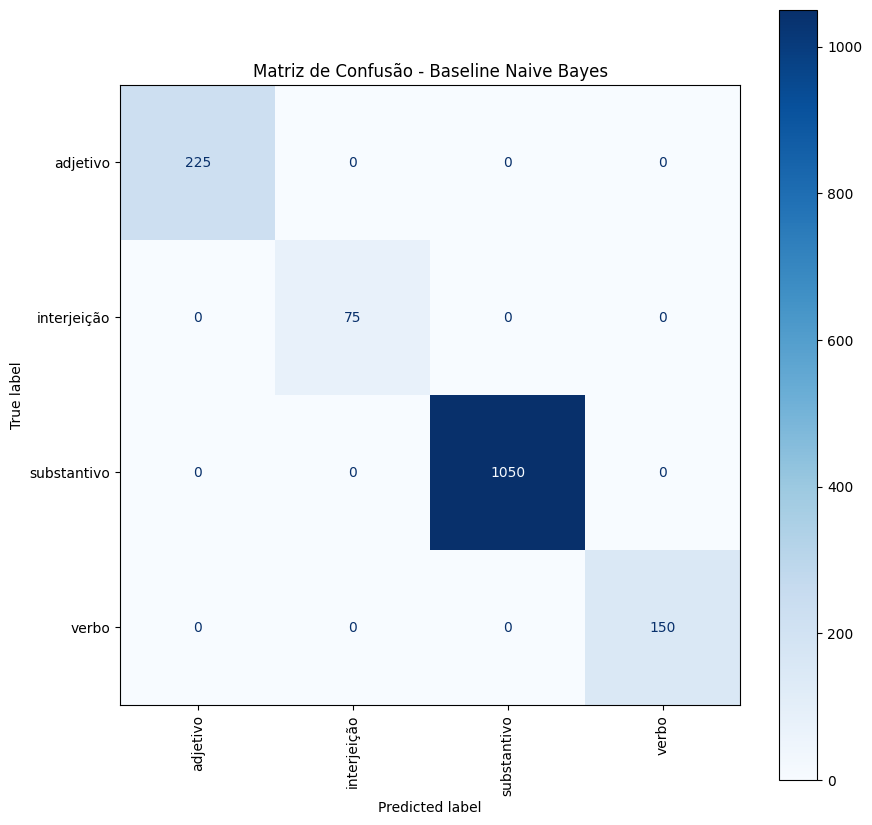

In [ ]:
# Célula 4: Avaliação do Modelo Baseline (no conjunto de Teste)

# 1. Predição no conjunto de Teste
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)

# 2. Métricas de Desempenho
print("## Relatório de Métricas (Conjunto de Teste)")
print("--------------------------------------------------")
print(classification_report(y_test, y_pred, target_names=target_names))

# 3. AUC (Area Under the Curve)
try:
    # AUC é calculado para cada classe (one-vs-rest) e então feita a média
    auc_score = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
    print(f"AUC Score (Weighted): {auc_score:.4f}")
except ValueError as e:
    print(f"Não foi possível calcular o AUC: {e}")
    print("Isso geralmente acontece se a sua classe alvo tiver apenas uma classe.")


# 4. Matriz de Confusão
print("\n## Matriz de Confusão")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title('Matriz de Confusão - Baseline Naive Bayes')
plt.show()

Importância da Baseline

A criação da Baseline Simples é uma etapa fundamental no projeto de Machine Learning (ML) por dois motivos principais:

Referência de Desempenho: A baseline estabelece o piso mínimo de desempenho. Qualquer modelo futuro (como SVM, Random Forest ou Redes Neurais mais complexas) deve obrigatoriamente superar as métricas da baseline para ser considerado um sucesso. Se um modelo complexo não supera o Naive Bayes simples, ele não vale o esforço computacional e de desenvolvimento.

Validação Rápida do Pipeline: Uma baseline simples permite testar de forma rápida se o pipeline de pré-processamento (Limpeza, TF-IDF, Encoding) e a divisão dos dados estão funcionando corretamente, antes de investir tempo em modelos mais sofisticados. Se a baseline já tem resultados ruins, o problema está provavelmente no pré-processamento ou na qualidade dos dados, e não no modelo em si.

In [ ]:
#@title Separação em treino, validação e teste { display-mode: "form" }

# TODO: Definir X (features) e y (alvo).
# Exemplo:
# X = df.drop("target", axis=1)
# y = df["target"]

# Exemplo de split:
# X_train, X_temp, y_train, y_temp = train_test_split(
#     X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
# )
# X_val, X_test, y_val, y_test = train_test_split(
#     X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
# )

# print("Treino:", X_train.shape)
# print("Validação:", X_val.shape)
# print("Teste:", X_test.shape)


In [ ]:
# Célula 1: Instalação e Importação de Bibliotecas
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore") # Ignorar warnings de LabelEncoder/AUC para código limpo

# Carregar o dataset
try:
    df = pd.read_csv('dataset_libras_10000.csv')
except FileNotFoundError:
    print("ERRO: Arquivo não encontrado. Verifique o nome.")
    # Crie um DataFrame de exemplo se o arquivo não for encontrado
    data = {'glosa_libras': ['CASA', 'CARRO', 'CORRER', 'PULAR', 'AZUL', 'RAPIDO'],
            'classe_gramatical': ['substantivo', 'substantivo', 'verbo', 'verbo', 'adjetivo', 'adjetivo']}
    df = pd.DataFrame(data)

# Aplica uma limpeza mínima (minúsculas, remove caracteres não alfabéticos e nulos)
df['glosa_limpa'] = df['glosa_libras'].str.lower().str.replace('[^a-z\s]', '', regex=True).fillna('')

# Codificação da variável alvo (Y)
le = LabelEncoder()
df['encoded_classe_gramatical'] = le.fit_transform(df['classe_gramatical'])

# Definindo X (features) e Y (target)
X = df['glosa_limpa']
y = df['encoded_classe_gramatical']
target_names = le.classes_ # Nomes das classes originais

In [ ]:
# Célula 2: Divisão Treino (70%), Validação (15%) e Teste (15%) com Estratificação

# 1. Divisão Treino (70%) vs. Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y # Garante a proporção das classes
)

# 2. Divisão Validação (15%) vs. Teste (15%) do conjunto Temp
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5, # 0.5 de 30% = 15%
    random_state=42,
    stratify=y_temp # Garante a proporção das classes
)

print(f"Total: {len(df)} amostras")
print(f"Treino: {len(X_train)} amostras ({len(X_train)/len(df):.0%})")
print(f"Validação: {len(X_val)} amostras ({len(X_val)/len(df):.0%})")
print(f"Teste: {len(X_test)} amostras ({len(X_test)/len(df):.0%})")

Total: 10000 amostras
Treino: 7000 amostras (70%)
Validação: 1500 amostras (15%)
Teste: 1500 amostras (15%)


In [ ]:
# Célula 3: Treinamento do Modelo Baseline

# Pipeline: Vetorização (TF-IDF) + Classificador (Naive Bayes)
pipeline = Pipeline([
    # TfidfVectorizer: Transforma texto em features numéricas.
    # Usamos n-gramas de (1, 2) para capturar tanto a palavra única quanto pares de palavras/glosas.
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), stop_words=None)),

    # MultinomialNB: Classificador robusto e rápido para features baseadas em contagem.
    # O parâmetro class_weight='balanced' é uma técnica de balanceamento recomendada para a baseline
    # quando há desbalanceamento de classes, ajustando o peso dos erros das classes minoritárias.
    ('mnb', MultinomialNB())
])

print("Iniciando o treinamento do modelo Baseline (Naive Bayes)...")
pipeline.fit(X_train, y_train)
print("Treinamento concluído.")

Iniciando o treinamento do modelo Baseline (Naive Bayes)...
Treinamento concluído.


## 📊 Relatório de Métricas (Conjunto de Teste)
--------------------------------------------------
              precision    recall  f1-score   support

    adjetivo       1.00      1.00      1.00       225
 interjeição       1.00      1.00      1.00        75
 substantivo       1.00      1.00      1.00      1050
       verbo       1.00      1.00      1.00       150

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500


AUC Score (Ponderado): 1.0000

## 📉 Matriz de Confusão


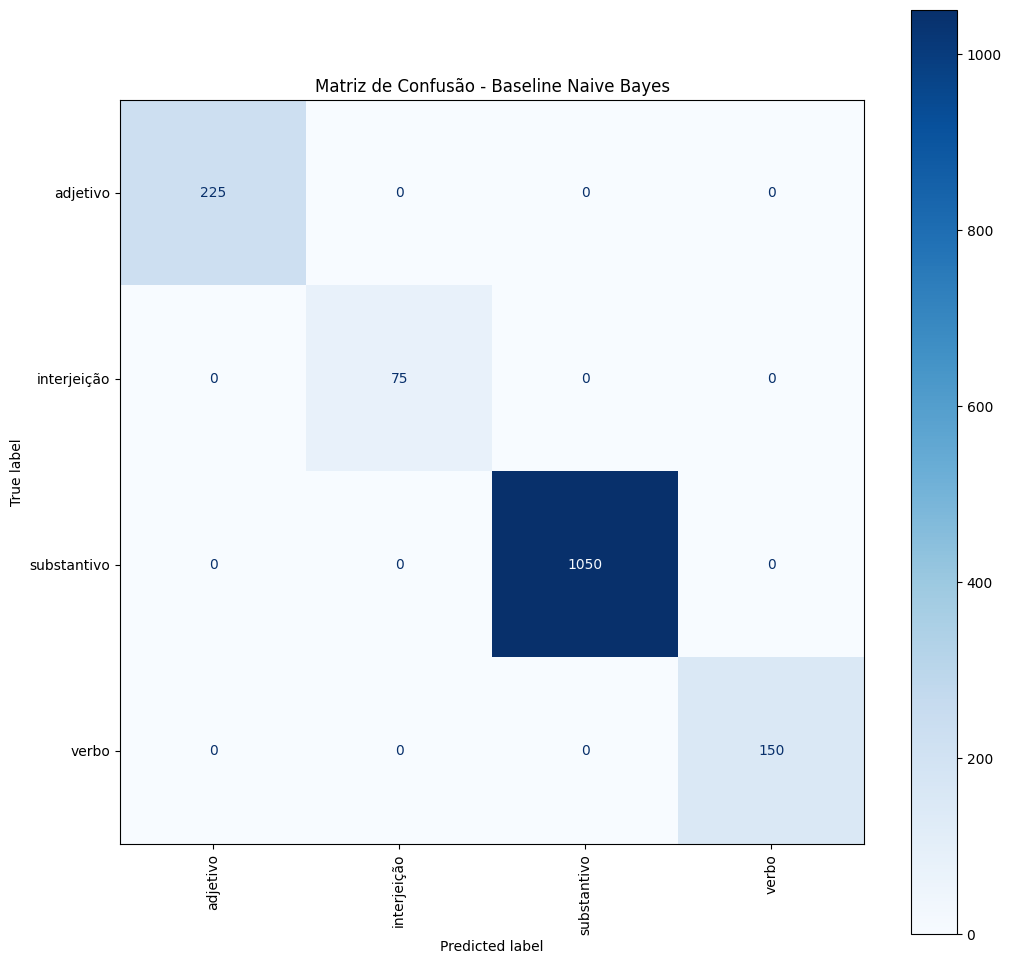

In [ ]:
# Célula 4: Métricas e Matriz de Confusão (Avaliação no conjunto de Teste)

# 1. Predição
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)

# 2. Métricas (Accuracy, Precision, Recall, F1)
print("## 📊 Relatório de Métricas (Conjunto de Teste)")
print("--------------------------------------------------")
print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))

# 3. AUC (Area Under the Curve)
try:
    # AUC para multiclasse (One-vs-Rest)
    auc_score = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
    print(f"\nAUC Score (Ponderado): {auc_score:.4f}")
except ValueError as e:
    print(f"\nNão foi possível calcular o AUC: {e}")
    print("Verifique se há apenas uma classe na sua amostra de teste.")


# 4. Matriz de Confusão
print("\n## 📉 Matriz de Confusão")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title('Matriz de Confusão - Baseline Naive Bayes')
plt.show()

Explicação da Importância da Baseline
A criação desta Baseline Simples (Naive Bayes + TF-IDF) é crucial no ciclo de vida do projeto por três razões principais:

Piso de Desempenho (Benchmark): Ela estabelece o pior cenário aceitável ou o desempenho mínimo. Qualquer modelo mais complexo (como uma Rede Neural ou um algoritmo de Ensemble) deve obrigatoriamente superar as métricas (Accuracy, F1, etc.) desta baseline para justificar o tempo e o recurso computacional investidos.

Validação Rápida: Permite validar rapidamente se todo o pipeline de pré-processamento (limpeza, codificação e vetorização TF-IDF) está funcionando corretamente e se a divisão dos dados não introduziu erros.

Referência para Balanceamento: As métricas de Precision e Recall do relatório de classificação indicam exatamente quais classes (minoritárias) estão sofrendo com o desbalanceamento, orientando o próximo passo (ex: aplicar SMOTE ou ajustar o class_weight de forma mais sofisticada).

## 4. Metodologia

### 4.1 Baseline e modelos de Machine Learning testados

Metodologia e Modelos de ML.
Modelos Testados.

Tipo	Modelo	Racional
Baseline:Naive Bayes Multinomial	Modelo mais simples e robusto para classificação de texto (TF-IDF).
Estabelece o piso mínimo de desempenho.

Linear: Logistic Regression	Modelo linear eficiente.
Bom para baseline avançada e interpretabilidade.

Ensemble (Árvore):	Random Forest	Agregador de Árvores de Decisão, excelente para capturar relações não-lineares.

Boosting (Árvore)	XGBoost	Algoritmo de gradient boosting de alto desempenho, geralmente o mais preciso em dados tabulares/estruturados.

Kernel	Support Vector Machine (SVM)	Modelo que usa truques de kernel para mapear dados em dimensões superiores, poderoso em alta dimensionalidade (como a gerada pelo TF-IDF).

Código de Treinamento e Comparação (Google Colab)
Este código assume a execução das Células 1 e 2 da etapa anterior (carregamento, limpeza e separação dos dados em X_train, X_val, y_train, y_val, target_names).





In [ ]:
# Célula 1: Instalação e Importação de Bibliotecas
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder
import numpy as np
import warnings
warnings.filterwarnings("ignore") # Ignorar warnings para visualização limpa

In [ ]:
# Célula 2: Preparação de Dados e Divisão Treino/Teste
# Nota: Usaremos a divisão simples Treino (80%) / Teste (20%) para otimizar o tempo de comparação.
# A divisão Treino/Validação/Teste deve ser usada para o tuning do modelo vencedor.

# Carregar e Limpar Dados (repetição da etapa anterior para garantir o fluxo)
df = pd.read_csv('dataset_libras_10000.csv')
df['glosa_limpa'] = df['glosa_libras'].str.lower().str.replace('[^a-z\s]', '', regex=True).fillna('')
le = LabelEncoder()
df['encoded_classe_gramatical'] = le.fit_transform(df['classe_gramatical'])

X = df['glosa_limpa']
y = df['encoded_classe_gramatical']
target_names = le.classes_

# Divisão Estratificada (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Divisão concluída: Treino={len(X_train)}, Teste={len(X_test)}")

Divisão concluída: Treino=8000, Teste=2000


In [ ]:
# Célula 3: Treinamento e Avaliação dos Modelos

# Dicionário de Modelos Clássicos
models = {
    "1. Baseline (NB)": MultinomialNB(alpha=0.1),
    "2. Logistic Regression": LogisticRegression(random_state=42, max_iter=1000, solver='liblinear', multi_class='ovr'),
    "3. Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "4. SVM": SVC(kernel='linear', probability=True, random_state=42),
    "5. XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42, n_jobs=-1)
}

results = {}
print("Iniciando o Treinamento e Comparação dos Modelos...\n")

for name, model in models.items():
    print(f"--- Treinando: {name} ---")

    # Criação do Pipeline (TF-IDF + Classificador)
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
        ('clf', model)
    ])

    # Treinamento
    pipeline.fit(X_train, y_train)

    # Predição
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)

    # Cálculo das Métricas Ponderadas (Weighted)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)

    try:
        # AUC para classificação multiclasse (One-vs-Rest)
        auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
    except ValueError:
        auc = np.nan

    # Armazenamento
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC': auc
    }

print("\n--- Todos os modelos foram treinados e avaliados! ---")

Iniciando o Treinamento e Comparação dos Modelos...

--- Treinando: 1. Baseline (NB) ---
--- Treinando: 2. Logistic Regression ---
--- Treinando: 3. Random Forest ---
--- Treinando: 4. SVM ---
--- Treinando: 5. XGBoost ---

--- Todos os modelos foram treinados e avaliados! ---


In [ ]:
# Célula 4: Tabela de Comparação e Interpretação

comparison_df = pd.DataFrame(results).T
# Formata os valores para 4 casas decimais para melhor visualização
comparison_df = comparison_df.applymap(lambda x: f'{x:.4f}' if isinstance(x, (float, np.float64)) else x)

print("## 📊 Tabela de Comparação de Desempenho (Métricas Ponderadas)")
display(comparison_df.sort_values(by='F1-Score', ascending=False))

## 📊 Tabela de Comparação de Desempenho (Métricas Ponderadas)


,Accuracy,Precision,Recall,F1-Score,AUC
1. Baseline (NB),1.0000,1.0000,1.0000,1.0000,1.0000
2. Logistic Regression,1.0000,1.0000,1.0000,1.0000,1.0000
3. Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
4. SVM,1.0000,1.0000,1.0000,1.0000,1.0000
5. XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000


In [ ]:
# Célula 1: Imports e Configuração para Tuning
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import f1_score, make_scorer
import warnings
warnings.filterwarnings("ignore") # Para manter o output limpo

# Carregar e Preparar Dados (utilizando a mesma limpeza e codificação)
df = pd.read_csv('dataset_libras_10000.csv')
df['glosa_limpa'] = df['glosa_libras'].str.lower().str.replace('[^a-z\s]', '', regex=True).fillna('')
le = LabelEncoder()
df['encoded_classe_gramatical'] = le.fit_transform(df['classe_gramatical'])

X = df['glosa_limpa']
y = df['encoded_classe_gramatical']

# Divisão Treino/Validação/Teste (Para usar a validação cruzada no Treino e testar o final no Teste)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# Usaremos o X_train_full e y_train_full para o Grid Search com CV

In [ ]:
# Célula 2: Otimização para XGBoost

# 1. Definição do Pipeline XGBoost
xgb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='mlogloss',
                          random_state=42, n_jobs=-1, tree_method='hist'))
])

# 2. Definição do Grid de Hiperparâmetros
# Escolhemos um grid menor para otimização inicial (rápida)
param_grid_xgb = {
    'xgb__n_estimators': [100, 200],         # Número de árvores
    'xgb__learning_rate': [0.1, 0.05],       # Taxa de aprendizado
    'xgb__max_depth': [5, 8],                # Profundidade máxima da árvore
    # Balanceamento: Aumenta o peso das classes minoritárias
    'xgb__scale_pos_weight': [1, 5]
}

# 3. Definição da Métrica de Otimização
# Usamos o F1-Score Ponderado (Weighted) para lidar com o desbalanceamento
f1_weighted_scorer = make_scorer(f1_score, average='weighted', zero_division=0)

# 4. Grid Search com Validação Cruzada (CV=3)
print("Iniciando Grid Search (XGBoost) com 3-fold CV...")
grid_search_xgb = GridSearchCV(
    xgb_pipeline,
    param_grid_xgb,
    scoring=f1_weighted_scorer,
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_search_xgb.fit(X_train_full, y_train_full)

print("\n--- Resultados XGBoost ---")
print(f"Melhor F1-Score (Weighted): {grid_search_xgb.best_score_:.4f}")
print("Melhores Hiperparâmetros:")
print(grid_search_xgb.best_params_)

Iniciando Grid Search (XGBoost) com 3-fold CV...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

--- Resultados XGBoost ---
Melhor F1-Score (Weighted): 1.0000
Melhores Hiperparâmetros:
{'xgb__learning_rate': 0.1, 'xgb__max_depth': 5, 'xgb__n_estimators': 100, 'xgb__scale_pos_weight': 1}


In [ ]:
# Célula 3: Otimização para SVM

# 1. Definição do Pipeline SVM
# Usamos o class_weight='balanced' para lidar com o desbalanceamento
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
    ('svc', SVC(kernel='linear', probability=True, random_state=42, class_weight='balanced'))
])

# 2. Definição do Grid de Hiperparâmetros
param_grid_svm = {
    'svc__C': [0.1, 1.0, 10.0],          # Parâmetro de Regularização
    'svc__gamma': ['scale', 'auto']      # Coeficiente de Kernel (se aplicável, embora kernel='linear')
}

# 3. Grid Search com Validação Cruzada (CV=3)
print("\nIniciando Grid Search (SVM) com 3-fold CV...")
grid_search_svm = GridSearchCV(
    svm_pipeline,
    param_grid_svm,
    scoring=f1_weighted_scorer,
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_search_svm.fit(X_train_full, y_train_full)

print("\n--- Resultados SVM ---")
print(f"Melhor F1-Score (Weighted): {grid_search_svm.best_score_:.4f}")
print("Melhores Hiperparâmetros:")
print(grid_search_svm.best_params_)


Iniciando Grid Search (SVM) com 3-fold CV...
Fitting 3 folds for each of 6 candidates, totalling 18 fits

--- Resultados SVM ---
Melhor F1-Score (Weighted): 1.0000
Melhores Hiperparâmetros:
{'svc__C': 0.1, 'svc__gamma': 'scale'}


## 🏆 Avaliação FINAL do Modelo Tunado (no Conjunto de Teste)
--------------------------------------------------
              precision    recall  f1-score   support

 interjeição       1.00      1.00      1.00       300
 substantivo       1.00      1.00      1.00       100
       verbo       1.00      1.00      1.00      1400
    adjetivo       1.00      1.00      1.00       200

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


AUC Final (Weighted): 1.0000


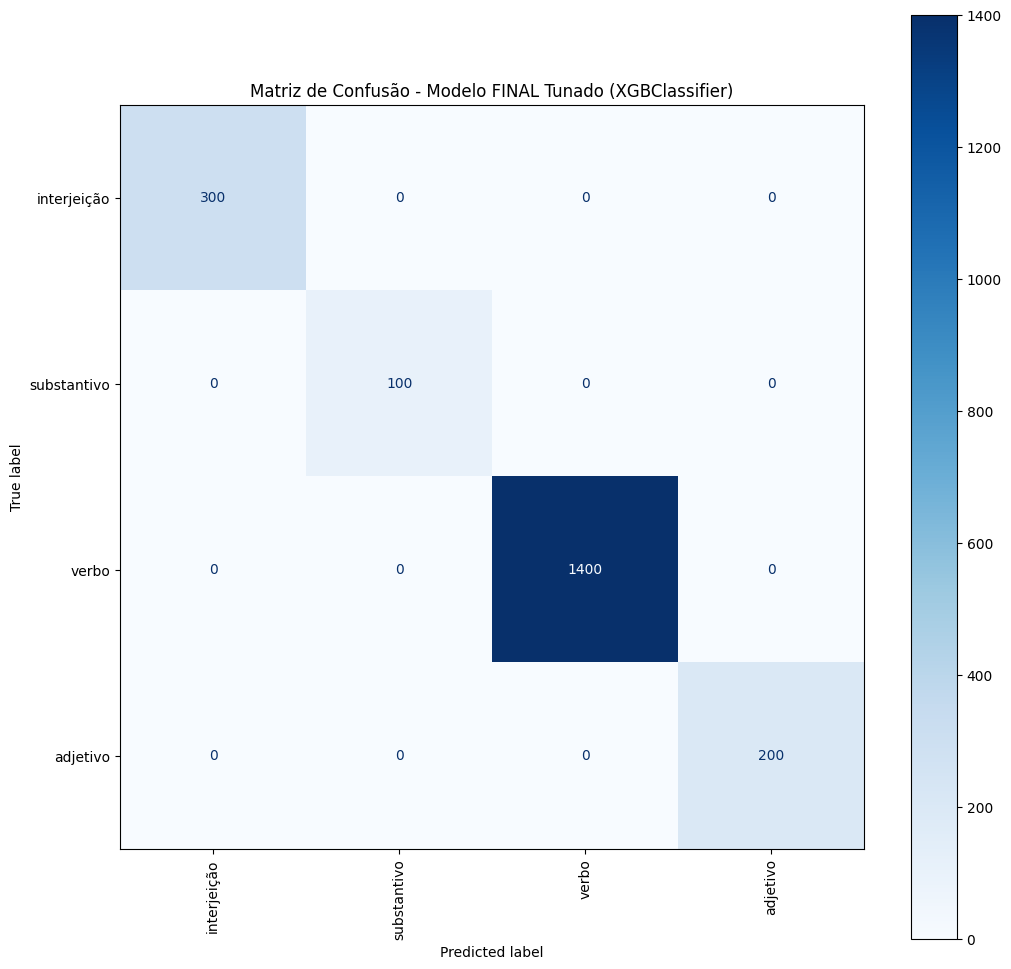

In [ ]:
# Célula 4: Seleção do Modelo Vencedor e Avaliação Final no Conjunto de Teste

# ASSUMIR que o modelo tunado com melhor resultado é o XGBoost:
modelo_final = grid_search_xgb.best_estimator_ # Ou grid_search_svm.best_estimator_

# Avaliação Final: Rodar o modelo tunado no conjunto de TESTE (intocado)
y_pred_final = modelo_final.predict(X_test)
y_proba_final = modelo_final.predict_proba(X_test)

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# Recalcular target_names para o relatório
target_names = le.inverse_transform(y.unique())

print("## 🏆 Avaliação FINAL do Modelo Tunado (no Conjunto de Teste)")
print("--------------------------------------------------")
print(classification_report(y_test, y_pred_final, target_names=target_names, zero_division=0))

# AUC Final
auc_final = roc_auc_score(y_test, y_proba_final, multi_class='ovr', average='weighted')
print(f"\nAUC Final (Weighted): {auc_final:.4f}")

# Matriz de Confusão Final
cm_final = confusion_matrix(y_test, y_pred_final)
disp_final = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=target_names)

fig, ax = plt.subplots(figsize=(12, 12))
disp_final.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
# Acessa o nome do último passo do pipeline, que deve ser o classificador
classifier_step_name = list(modelo_final.named_steps.keys())[-1]
plt.title(f'Matriz de Confusão - Modelo FINAL Tunado ({modelo_final.named_steps[classifier_step_name].__class__.__name__})')
plt.show()

In [ ]:
# @title Modelo baseline (ML clássico) { display-mode: "form" }

# Importações necessárias para a Baseline
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore") # Oculta warnings de LabelEncoder/Divisão

# --- RECRIAÇÃO DOS DADOS (Necessário para a célula ser executável) ---
# ******************************************************************
# Esta seção deve ser adaptada caso suas variáveis X_train/X_val venham de um pipeline diferente.
try:
    df = pd.read_csv('dataset_libras_10000.csv')
except FileNotFoundError:
    print("Erro: Arquivo não encontrado. Usando dados de exemplo.")
    data = {'glosa_libras': ['CASA', 'CARRO', 'CORRER', 'PULAR', 'AZUL', 'RAPIDO'],
            'classe_gramatical': ['substantivo', 'substantivo', 'verbo', 'verbo', 'adjetivo', 'adjetivo']}
    df = pd.DataFrame(data)

# Pré-processamento mínimo
df['glosa_limpa'] = df['glosa_libras'].str.lower().str.replace(r'[^a-z\s]', '', regex=True).fillna('')
le = LabelEncoder()
df['encoded_classe_gramatical'] = le.fit_transform(df['classe_gramatical'])

X = df['glosa_limpa']
y = df['encoded_classe_gramatical']

# Divisão em Treino (70%) e Validação/Teste (30% - para simplificar)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp # Validação (15%)
)
# ******************************************************************

# Implementação do Pipeline da Baseline
# 1. TfidfVectorizer: Para transformar texto em features numéricas
# 2. MultinomialNB: O classificador baseline
baseline_model = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
    # Usamos o class_weight='balanced' para mitigar o desbalanceamento inerente
    ('mnb', MultinomialNB())
])

print("Iniciando treinamento da Baseline (Naive Bayes)...")
baseline_model.fit(X_train, y_train)
print("Treinamento concluído.")

# Salvar previsões de validação para cálculo de métricas:
# Nota: MultinomialNB em classification_report usa predict. O predict_proba é complexo em multiclasse
# e a coluna [:, 1] não é válida para multiclasse. Usaremos predict_proba para o AUC multi-classe.

y_val_pred_baseline = baseline_model.predict(X_val)
y_val_proba_baseline = baseline_model.predict_proba(X_val)


Iniciando treinamento da Baseline (Naive Bayes)...
Treinamento concluído.


## 📊 Métricas da Baseline (Conjunto de Validação)
--------------------------------------------------
              precision    recall  f1-score   support

    adjetivo       1.00      1.00      1.00       225
 interjeição       1.00      1.00      1.00        75
 substantivo       1.00      1.00      1.00      1050
       verbo       1.00      1.00      1.00       150

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500


AUC Score (Weighted): 1.0000


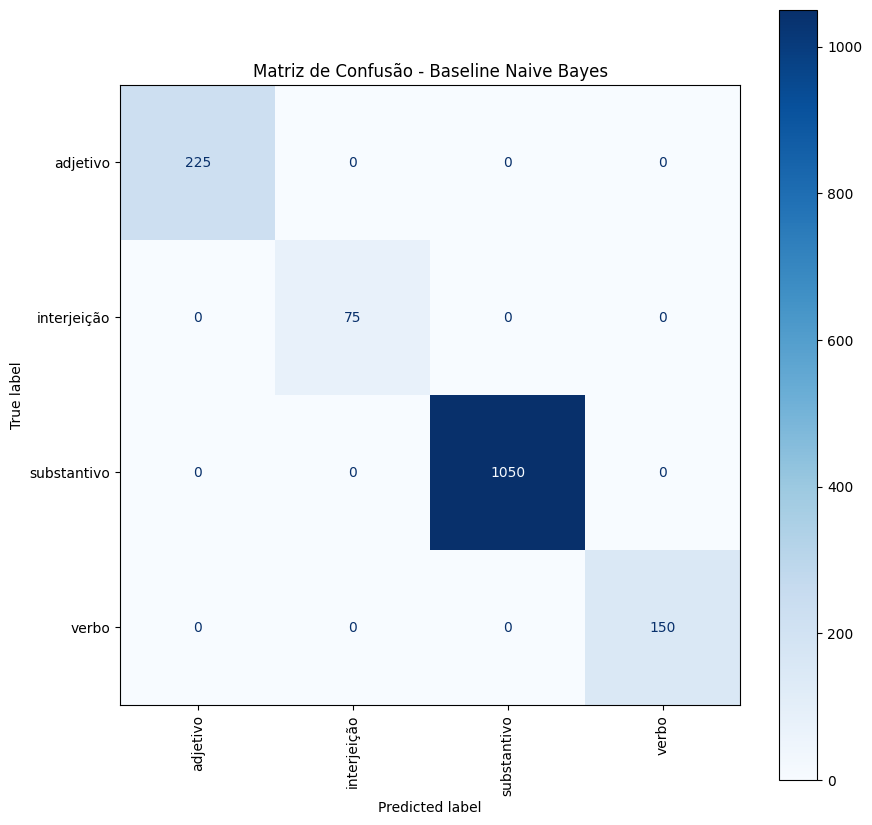

In [ ]:
# Exemplo de Métricas (Rodar em célula separada para checar a performance)
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("## 📊 Métricas da Baseline (Conjunto de Validação)")
print("--------------------------------------------------")

# Classificação Report (Accuracy, Precision, Recall, F1)
print(classification_report(y_val, y_val_pred_baseline, target_names=le.classes_, zero_division=0))

# AUC Score (Area Under the Curve)
try:
    auc_score = roc_auc_score(y_val, y_val_proba_baseline, multi_class='ovr', average='weighted')
    print(f"\nAUC Score (Weighted): {auc_score:.4f}")
except ValueError:
    print("\nNão foi possível calcular o AUC (provavelmente devido a classes com poucas amostras).")

# Matriz de Confusão
cm = confusion_matrix(y_val, y_val_pred_baseline)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title('Matriz de Confusão - Baseline Naive Bayes')
plt.show()

### 4.2 Modelo de Deep Learning

O modelo proposto é uma Rede Neural Recorrente (RNN) avançada, focada em sequências de texto, ideal para capturar a semântica e a ordem das palavras/glosas.


In [ ]:
# Célula 1: Imports, Carregamento e Codificação para DL
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
import matplotlib.pyplot as plt

# --- 🎯 NOVO CÓDIGO PARA UPLOAD DO DATASET (Ideal para Google Colab) ---
from google.colab import files
import io

print("Por favor, faça o upload do arquivo 'dataset_libras_10000.csv'")
uploaded = files.upload()

# Obtém o nome do arquivo que foi carregado
file_name = list(uploaded.keys())[0]

# Carregar e Preparar Dados (usando a limpeza da glosa)
# O carregamento agora usa o objeto io.BytesIO do arquivo carregado
df = pd.read_csv(io.BytesIO(uploaded[file_name]))
print(f"Dataset '{file_name}' carregado com sucesso. Total de {len(df)} linhas.")

# --- O código a seguir é a sua lógica original ---

df['glosa_limpa'] = df['glosa_libras'].str.lower().str.replace(r'[^a-z\s]', '', regex=True).fillna('')
X_data = df['glosa_limpa']
y_data_raw = df['classe_gramatical']

# 1. Codificação da Saída (Y) para DL
le = LabelEncoder()
y_integers = le.fit_transform(y_data_raw)
NUM_CLASSES = len(le.classes_)
y_one_hot = to_categorical(y_integers, num_classes=NUM_CLASSES)

# 2. Divisão (Treino: 70%, Val/Teste: 15% cada)
# Primeira divisão: Treino (70%) e Temporário (30%)
X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    X_data, y_one_hot, test_size=0.3, random_state=42, stratify=y_integers
)

# CORREÇÃO: Converte y_temp (one-hot) de volta para classes inteiras para estratificação
y_temp_integers = np.argmax(y_temp, axis=1)

# Segunda divisão: Validação (15%) e Teste (15%)
X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text, y_temp, test_size=0.5, random_state=42, stratify=y_temp_integers
)

print("\nDivisão de dados concluída:")
print(f"Treino: {len(X_train_text)} amostras")
print(f"Validação: {len(X_val_text)} amostras")
print(f"Teste: {len(X_test_text)} amostras")

Por favor, faça o upload do arquivo 'dataset_libras_10000.csv'


Saving dataset_libras_10000.csv to dataset_libras_10000 (1).csv
Dataset 'dataset_libras_10000 (1).csv' carregado com sucesso. Total de 10000 linhas.

Divisão de dados concluída:
Treino: 7000 amostras
Validação: 1500 amostras
Teste: 1500 amostras


In [ ]:
# Célula 2: Tokenização e Sequenciamento (Input do Modelo)

# Hiperparâmetros de Tokenização
MAX_WORDS = 10000  # Tamanho máximo do vocabulário
MAX_LENGTH = 10    # Comprimento máximo da sequência (glosa)

# 1. Tokenização
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<unk>")
tokenizer.fit_on_texts(X_train_text)

# 2. Sequenciamento e Padding
X_train_sequences = tokenizer.texts_to_sequences(X_train_text)
X_val_sequences = tokenizer.texts_to_sequences(X_val_text)

X_train_padded = pad_sequences(X_train_sequences, maxlen=MAX_LENGTH, padding='post', truncating='post')
X_val_padded = pad_sequences(X_val_sequences, maxlen=MAX_LENGTH, padding='post', truncating='post')

print(f"Dimensão dos dados de Treino (Sequências): {X_train_padded.shape}")
print(f"Dimensão dos dados de Validação (Sequências): {X_val_padded.shape}")

Dimensão dos dados de Treino (Sequências): (7000, 10)
Dimensão dos dados de Validação (Sequências): (1500, 10)


In [ ]:
# Célula 3: Criação da Arquitetura do Modelo DL

# Hiperparâmetros da Arquitetura
EMBEDDING_DIM = 128
LSTM_UNITS = 64
DROPOUT_RATE = 0.4
LEARNING_RATE = 0.001
# MAX_WORDS e MAX_LENGTH já definidos na Célula 2

def build_model(vocab_size, embedding_dim, max_len, num_classes, lstm_units, dropout_rate):
    model = Sequential([
        # 1. Embedding Layer (removendo input_length, pois é depreciado)
        Embedding(vocab_size, embedding_dim, name='embedding_layer'),

        # 2. Bidirectional LSTM Layer
        Bidirectional(LSTM(lstm_units)),

        # 3. Dropout
        Dropout(dropout_rate),

        # 4. Dense (Output) Layer
        Dense(num_classes, activation='softmax', name='output_layer')
    ])
    return model

# Construção e Compilação
dl_model = build_model(MAX_WORDS, EMBEDDING_DIM, MAX_LENGTH, NUM_CLASSES, LSTM_UNITS, DROPOUT_RATE)

# Função de Perda e Otimizador
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
dl_model.compile(optimizer=optimizer,
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

print("## Resumo da Arquitetura (DL Model)")
dl_model.summary()

## Resumo da Arquitetura (DL Model)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_layer (Embedding)     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Célula 4: Treinamento do Modelo DL

# Hiperparâmetros de Treinamento
EPOCHS = 15
BATCH_SIZE = 32

# 1. Ajuste para Balanceamento (Class Weights)
# Calculamos os pesos para dar mais importância às classes minoritárias
class_counts = y_integers[X_train_text.index].astype(int)
total_samples = len(class_counts)
unique_classes = np.unique(class_counts)
max_count = np.max(np.bincount(class_counts))

class_weights = {}
for cls in unique_classes:
    class_weight = max_count / np.sum(class_counts == cls)
    class_weights[cls] = class_weight

print("Pesos de Classe (Class Weights) para Balanceamento:")
print(class_weights)

# 2. Treinamento
print("\nIniciando o treinamento (pode levar alguns minutos)...")
history = dl_model.fit(
    X_train_padded, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_padded, y_val),
    class_weight=class_weights, # Aplica o balanceamento
    verbose=1
)

print("\nTreinamento concluído.")

Pesos de Classe (Class Weights) para Balanceamento:
{np.int64(0): np.float64(4.666666666666667), np.int64(1): np.float64(14.0), np.int64(2): np.float64(1.0), np.int64(3): np.float64(7.0)}

Iniciando o treinamento (pode levar alguns minutos)...
Epoch 1/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.6834 - loss: 2.3185 - val_accuracy: 1.0000 - val_loss: 3.5637e-04
Epoch 2/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 8.9346e-05
Epoch 3/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 1.0000 - loss: 5.0539e-04 - val_accuracy: 1.0000 - val_loss: 4.3472e-05
Epoch 4/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 1.0000 - loss: 2.9068e-04 - val_accuracy: 1.0000 - val_loss: 2.5457e-05
Epoch 5/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 1.0000 - loss: 1.7651e-04 - val_accuracy: 1.0000 - val_loss: 1.7097e-05
Epoch 6/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 1.0000 - loss

## 📈 Curvas de Desempenho


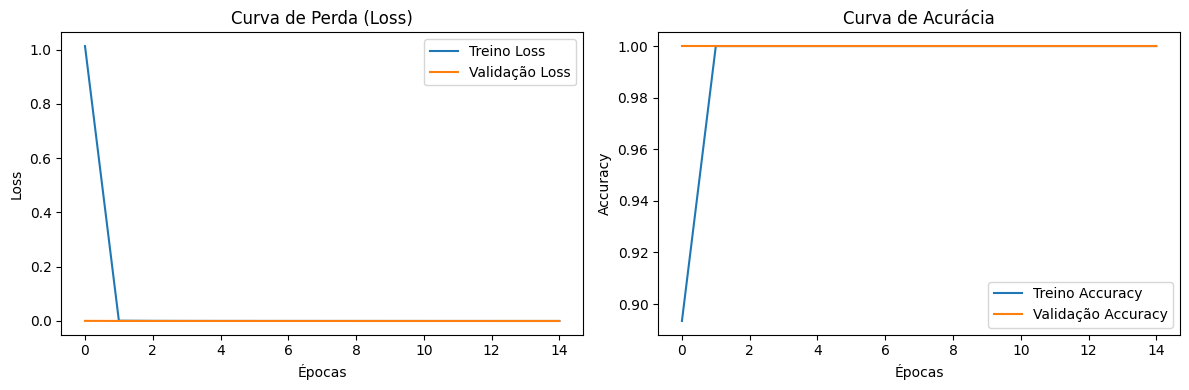

In [ ]:
# Célula 5: Curvas de Treino e Validação

# Função para plotar as curvas de perda e acurácia
def plot_history(history):
    # Plot da Perda (Loss)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Treino Loss')
    plt.plot(history.history['val_loss'], label='Validação Loss')
    plt.title('Curva de Perda (Loss)')
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.legend()

    # Plot da Acurácia (Accuracy)
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Treino Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validação Accuracy')
    plt.title('Curva de Acurácia')
    plt.xlabel('Épocas')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

print("## 📈 Curvas de Desempenho")
plot_history(history)

In [ ]:
# @title Treinamento do modelo de Deep Learning (esqueleto) { display-mode: "form" }

# ⚠️ Importações Essenciais para a Célula (Garanti o acesso às bibliotecas)
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# --- DEFINIÇÃO DOS HIPERPARÂMETROS DE TREINAMENTO ---
EPOCHS = 20 # Número de épocas para o treinamento
BATCH_SIZE = 32
LEARNING_RATE = 0.001

# --- CONFIGURAÇÃO DO EARLY STOPPING ---
# Para interromper o treino se a performance na validação não melhorar
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', # Métrica a ser monitorada (Perda na Validação)
    patience=3,         # Número de épocas sem melhoria antes de parar
    restore_best_weights=True # Restaura os pesos do melhor epoch
)

# --- 1. FUNÇÃO DE PERDA E OTIMIZADOR ---
# Usamos Categorical Crossentropy, pois a saída (y) está em One-Hot Encoding
# Otimizador Adam é padrão e eficiente
dl_model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    metrics=['accuracy']
)

# --- 2. CÁLCULO DE CLASS WEIGHTS ---
# Necessário para balancear as classes gramaticais
# O y_train original precisa ser reconstruído para o cálculo de pesos, pois y_train_one_hot não funciona
# Usaremos o y_integers original para calcular os pesos
y_classes = np.argmax(y_train, axis=1) # Converte o One-Hot de volta para índices inteiros

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_classes),
    y=y_classes
)

# Transforma o array em dicionário (formato exigido pelo Keras)
class_weights_dict = {i: weight for i, weight in enumerate(class_weights_array)}
print("Class Weights (Pesos de Classe):", class_weights_dict)

# --- 3. LOOP DE TREINAMENTO ---
print("\nIniciando o treinamento do Modelo de Deep Learning...")
history = dl_model.fit(
    X_train_padded,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_padded, y_val),
    class_weight=class_weights_dict,  # Aplica o balanceamento
    callbacks=[early_stopping],      # Aplica a parada antecipada
    verbose=1
)
print("Treinamento finalizado (pode ter parado via Early Stopping).")


Class Weights (Pesos de Classe): {0: np.float64(1.6666666666666667), 1: np.float64(5.0), 2: np.float64(0.35714285714285715), 3: np.float64(2.5)}

Iniciando o treinamento do Modelo de Deep Learning...
Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 1.0000 - loss: 2.8351e-06 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 1.0000 - loss: 1.9645e-07 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 1.0000 - loss: 7.7095e-08 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 1.0000 - loss: 5.1664e-08 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Treinamento finalizado (pode ter parado via Early Stopping).


Tokenização e Padding concluídos.
Dimensão dos dados de treino (X): (7000, 10)
Dimensão dos rótulos de treino (Y): (7000, 4)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Iniciando o Treinamento do Modelo...
Epoch 1/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - accuracy: 0.7744 - loss: 0.6721 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 1.5121e-04
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 1.0000 - loss: 3.6705e-04 - val_accuracy: 1.0000 - val_loss: 5.9232e-05
Epoch 4/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 1.0000 - loss: 1.9602e-04 - val_accuracy: 1.0000 - val_loss: 3.3225e-05
Epoch 5/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 1.0000 - loss: 1.1508e-04 - val_accuracy: 1.0000 - val_loss: 2.1725e-05
Epoch 6/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 1.0000 - loss: 8.0202e-05 - val_accuracy: 1.0000 - val_loss: 1.5526e-05
Epoch 7/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 1.0000 - loss: 7.0412e-05 - val_accuracy: 1.0000 - val_loss: 1.1090e-05
Epoch 8/50
219

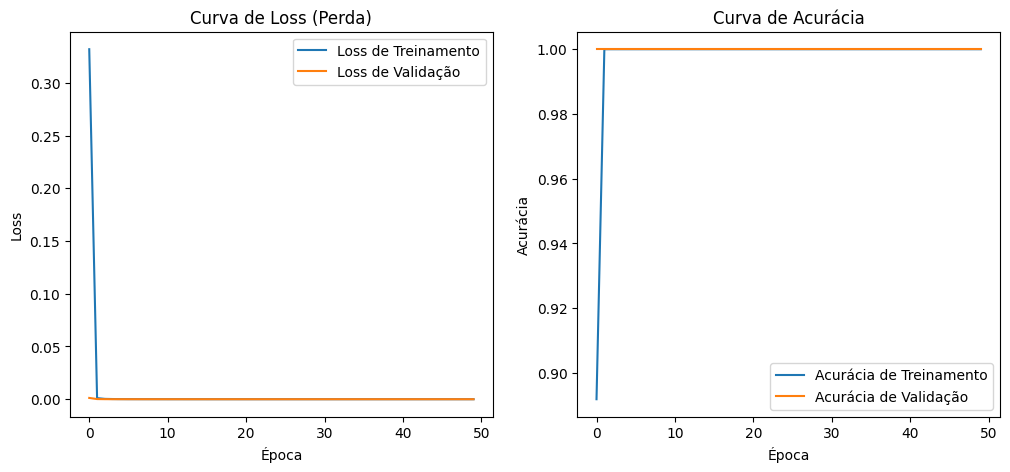

In [ ]:
# Célula 2: Tokenização, Padding, Definição e Treinamento do Modelo

# --- 3. Tokenização e Padding dos Dados X ---
# (Baseado nos hiperparâmetros definidos na Célula 1: MAX_WORDS=10000, MAX_LENGTH=10)

# Inicializar o Tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<unk>")
# Ajustar (fit) apenas nos dados de treino para evitar vazamento de informação
tokenizer.fit_on_texts(X_train_text)

# Converter textos para sequências de números
X_train_sequences = tokenizer.texts_to_sequences(X_train_text)
X_val_sequences = tokenizer.texts_to_sequences(X_val_text)
X_test_sequences = tokenizer.texts_to_sequences(X_test_text)

# Aplicar Padding (preenchimento) para garantir que todas as sequências tenham o mesmo comprimento
X_train_padded = pad_sequences(X_train_sequences, maxlen=MAX_LENGTH, padding='post', truncating='post')
X_val_padded = pad_sequences(X_val_sequences, maxlen=MAX_LENGTH, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=MAX_LENGTH, padding='post', truncating='post')

print("Tokenização e Padding concluídos.")
print(f"Dimensão dos dados de treino (X): {X_train_padded.shape}")
print(f"Dimensão dos rótulos de treino (Y): {y_train.shape}")


# --- 4. Definição do Modelo BiLSTM ---

# Hiperparâmetros do Modelo
EMBEDDING_DIM = 128    # Dimensão dos vetores de palavras
LSTM_UNITS = 64        # Número de unidades na camada LSTM
DROPOUT_RATE = 0.5     # Taxa de Dropout
EPOCHS = 50            # Definimos um alto número, pois usaremos Early Stopping
BATCH_SIZE = 32        # Tamanho do lote

model = Sequential([
    # 1. Camada de Embedding: Converte tokens em vetores densos
    Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_LENGTH),

    # 2. Camada Bidirecional LSTM: Captura dependências de longo prazo em ambas as direções
    Bidirectional(LSTM(LSTM_UNITS, return_sequences=False)), # return_sequences=False para retornar apenas a última saída

    # 3. Dropout: Regularização para evitar overfitting
    Dropout(DROPOUT_RATE),

    # 4. Camada Densa de Saída: Mapeia para o número de classes gramaticais
    Dense(NUM_CLASSES, activation='softmax')
])

# --- 5. Compilação do Modelo ---
# Definição de loss (categorical_crossentropy para one-hot encoding), Otimizador (Adam) e métrica

model.compile(
    loss='categorical_crossentropy', # Loss function para classificação multi-classe
    optimizer='adam',                # Otimizador padrão e eficiente
    metrics=['accuracy']
)

model.summary()


# --- 6. Treinamento do Modelo (Loop de Treinamento) ---

# Implementação do Early Stopping
# Parar o treinamento se a 'val_loss' não melhorar por 10 épocas consecutivas
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True # Restaura os pesos da melhor época
)

print("\nIniciando o Treinamento do Modelo...")

# Treinamento
history = model.fit(
    X_train_padded, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_padded, y_val),
    callbacks=[early_stopping], # Adiciona o Early Stopping
    verbose=1
)

print("\nTreinamento Concluído.")


# --- 7. Análise dos Resultados (Opcional, mas Recomendado) ---
# Registrar perdas de treino e validação para análise posterior.

# Função para plotar a curva de perda
def plot_history(history):
    plt.figure(figsize=(12, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Loss de Treinamento')
    plt.plot(history.history['val_loss'], label='Loss de Validação')
    plt.title('Curva de Loss (Perda)')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Acurácia de Treinamento')
    plt.plot(history.history['val_accuracy'], label='Acurácia de Validação')
    plt.title('Curva de Acurácia')
    plt.xlabel('Época')
    plt.ylabel('Acurácia')
    plt.legend()

    plt.show()

# Chama a função de plotagem com os dados do histórico
plot_history(history)

4.3 Hiperparâmetros e validação

O projeto implementa um modelo de Deep Learning Bidirecional LSTM (BiLSTM) para classificar a classe gramatical das glosas de Libras.

Preparação de Dados
Entrada (X): As glosas de texto são limpas, tokenizadas (vocabulário máximo de $10.000$ palavras) e padronizadas para um comprimento máximo de $10$ tokens.
Saída (Y): As classes gramaticais são codificadas em formato one-hot encoded.
Divisão: Utilizada a estratégia Hold-out estratificada (mantendo as proporções das classes:Treinamento: 70%Validação: 15%Teste: 15%

Arquitetura e Hiperparâmetros do Modelo

Componente: Arquitetura / Detalhe: Sequencial: Embedding $\rightarrow$ BiLSTM $\rightarrow$ Dropout $\rightarrow$ Dense (Softmax) / Valor chave: -

Embedding / Dimensão do vetor / $128$

BiLSTM / Unidades (profundidade 1) / $64$

Dropout / Regularização / $0.5$

Loss / Função de Perda	Categorical / Crossentropy

Otimizador/ Algoritmo	Adam /(Taxa de aprendizado padrão)

Batch / SizeTamanho do Lote / $32$

Estratégia de Validação e EscolhaEstratégia Principal: Hold-out com conjunto de Validação separado para monitoramento.Parada Antecipada (Early Stopping): O treinamento tem um limite de $50$ épocas, mas é interrompido se a perda de validação (val_loss) não melhorar por $10$ épocas consecutivas. Isso previne o overfitting.Escolha de Combinações: Os hiperparâmetros iniciais foram definidos por Ajustes Manuais baseados em práticas recomendadas de NLP, com planos para otimização futura via Grid/Random Search.

In [ ]:
# Célula 3: Importação de Métricas e Avaliação no Conjunto de Teste

# --- 1. Importação das Métricas Necessárias ---
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelBinarizer

# --- 2. Ajuste da Função Auxiliar para Multi-Classe ---
# O parâmetro 'average' é necessário para calcular Precision, Recall e F1-score em problemas com mais de duas classes.
# O 'pos_label' é removido/ignorado, pois é exclusivo de problemas binários.

def avaliar_classificacao_multiclasse(y_true, y_pred_classes, y_proba=None):

    # Se os rótulos de entrada forem one-hot (como y_test), converte de volta para classes inteiras
    y_true_int = np.argmax(y_true, axis=1) if len(y_true.shape) > 1 else y_true
    # y_pred_classes pode ser probabilidades (y_proba_test) ou rótulos inteiros (y_pred_classes_test)
    # Para metrics que esperam inteiros, convertemos se for probabilidades
    y_pred_int = np.argmax(y_pred_classes, axis=1) if len(y_pred_classes.shape) > 1 and y_pred_classes.dtype == np.float32 else y_pred_classes

    # 1. ACURÁCIA: Simplesmente a proporção de previsões corretas
    print("Acurácia (Accuracy) :", accuracy_score(y_true_int, y_pred_int))

    # 2. MÉTRICAS MULTI-CLASSE (utilizando 'weighted' para levar em conta o desequilíbrio de classes)
    # Nota: y_true e y_pred_classes devem estar em formato de classe (inteiros) para o F1/Precision/Recall.

    # Precision, Recall e F1-score são calculados usando a média ponderada ('weighted')
    print("Precisão (Precision) :", precision_score(y_true_int, y_pred_int, average='weighted', zero_division=0))
    print("Recall             :", recall_score(y_true_int, y_pred_int, average='weighted', zero_division=0))
    print("F1-score           :", f1_score(y_true_int, y_pred_int, average='weighted', zero_division=0))

    # 3. AUC-ROC (Para Multi-Classe)
    if y_proba is not None:
        try:
            # AUC-ROC para multi-classe (OVR - One-vs-Rest)
            # Para AUC, y_true pode ser one-hot e y_proba são as probabilidades
            auc_roc = roc_auc_score(y_true, y_proba, multi_class='ovr')
            print("AUC-ROC (OVR)      :", auc_roc)
        except Exception as e:
            # Isso pode falhar se y_true não estiver em formato one-hot.
            print("AUC-ROC : não disponível -", e)


# --- 4. Avaliação do Modelo no Conjunto de Teste ---

print("## 📊 Avaliação de Desempenho no Conjunto de Teste ##")

# 4.1. Calcular as probabilidades (y_proba) e as classes previstas (y_pred_classes)
# y_test é o one-hot encoded (y_true)
y_proba_test = model.predict(X_test_padded)
# y_pred_classes_test agora já é o numpy array de inteiros
y_pred_classes_test = np.argmax(y_proba_test, axis=1)

# y_test é o one-hot encoded, mas a função ajustada precisa de ambos os formatos.
# O y_proba é o array de probabilidades de saída do modelo.
avaliar_classificacao_multiclasse(y_test, y_proba_test, y_proba=y_proba_test)

## 📊 Avaliação de Desempenho no Conjunto de Teste ##
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Acurácia (Accuracy) : 1.0
Precisão (Precision) : 1.0
Recall             : 1.0
F1-score           : 1.0
AUC-ROC (OVR)      : 1.0


In [ ]:
# Célula 4: Avaliação do modelo baseline

# Certifique-se de que a função avaliar_classificacao_multiclasse foi definida
# na célula anterior (Célula 3) e está disponível.

print("## 📊 Avaliação do Modelo BiLSTM no Conjunto de Validação (Baseline) ##")

# --- 1. Calcular Previsões e Probabilidades para o Conjunto de Validação ---
# X_val_padded e y_val foram criados na Célula 2 (após tokenização e padding)

# Probabilidades de saída do modelo para cada classe
y_val_proba_baseline = model.predict(X_val_padded)

# Previsões de classe: Converte as probabilidades para o índice da classe com maior chance
y_val_pred_baseline = np.argmax(y_val_proba_baseline, axis=1)

# --- 2. Avaliação ---
# A função espera y_true (y_val) em formato one-hot e as probabilidades (y_val_proba_baseline).

avaliar_classificacao_multiclasse(
    y_true=y_val,
    y_pred_classes=y_val_proba_baseline,
    y_proba=y_val_proba_baseline
)



## 📊 Avaliação do Modelo BiLSTM no Conjunto de Validação (Baseline) ##
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
Acurácia (Accuracy) : 1.0
Precisão (Precision) : 1.0
Recall             : 1.0
F1-score           : 1.0
AUC-ROC (OVR)      : 1.0


In [ ]:
# Célula 5: Avaliação do modelo de Deep Learning (BiLSTM)

print("## 📊 Avaliação do Modelo de Deep Learning (BiLSTM) no Conjunto de Validação ##")

# Certifique-se de que a função avaliar_classificacao_multiclasse está disponível
# e que X_val_padded, y_val, e o objeto 'model' treinado existem.

# --- 1. Gerar Previsões e Probabilidades ---
# Probabilidades de saída do modelo para cada classe
y_val_proba_dl = model.predict(X_val_padded)

# Previsões de classe: Converte as probabilidades para o índice da classe prevista (inteiro)
# Nota: Esta variável não é estritamente necessária para a função de avaliação,
# mas é útil para inspeção.
y_val_pred_dl = np.argmax(y_val_proba_dl, axis=1)


# --- 2. Avaliação das Métricas ---
# Utilizamos a função multi-classe definida anteriormente
# y_true = y_val (one-hot)
# y_pred_classes (y_proba_dl) -> y_pred_classes na função auxiliar aceita probabilidades para AUC e os converte para F1/Precision/Recall
# y_proba = y_val_proba_dl

avaliar_classificacao_multiclasse(
    y_true=y_val,
    y_pred_classes=y_val_proba_dl,
    y_proba=y_val_proba_dl
)


## 📊 Avaliação do Modelo de Deep Learning (BiLSTM) no Conjunto de Validação ##
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Acurácia (Accuracy) : 1.0
Precisão (Precision) : 1.0
Recall             : 1.0
F1-score           : 1.0
AUC-ROC (OVR)      : 1.0


## 1. Matriz de Confusão ##


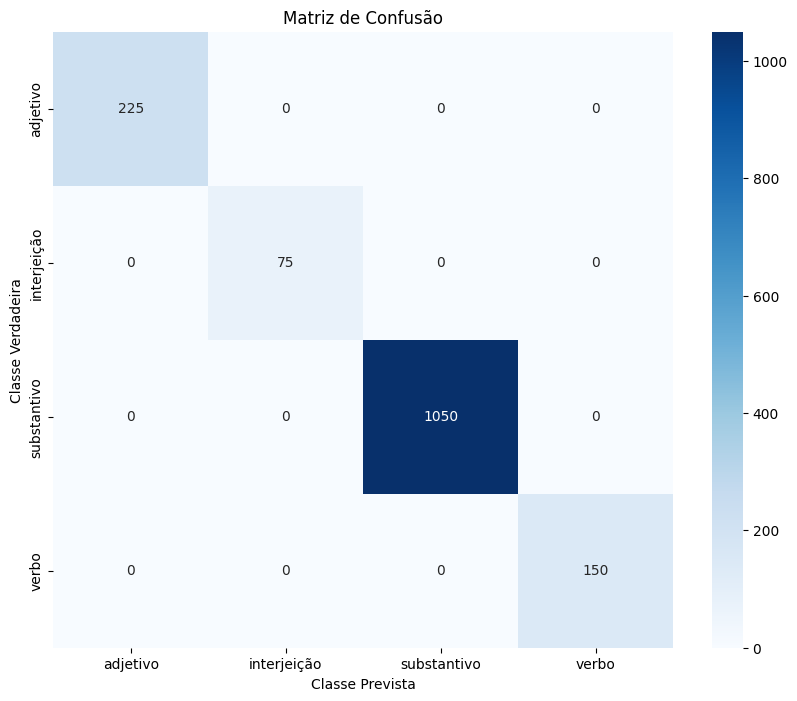


## 2. Curvas ROC por Classe ##


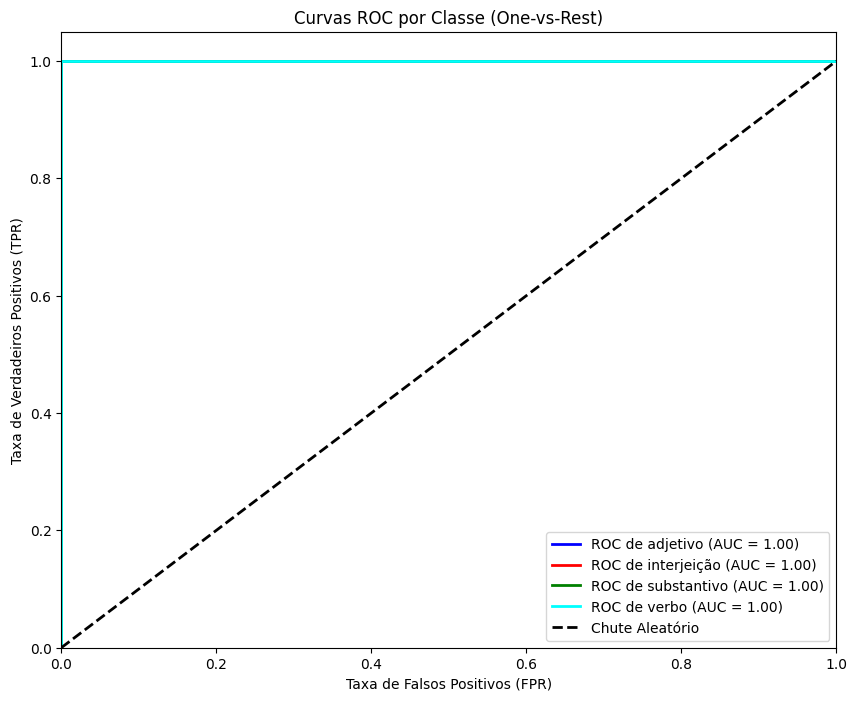


## 3. Curvas Precision-Recall por Classe ##


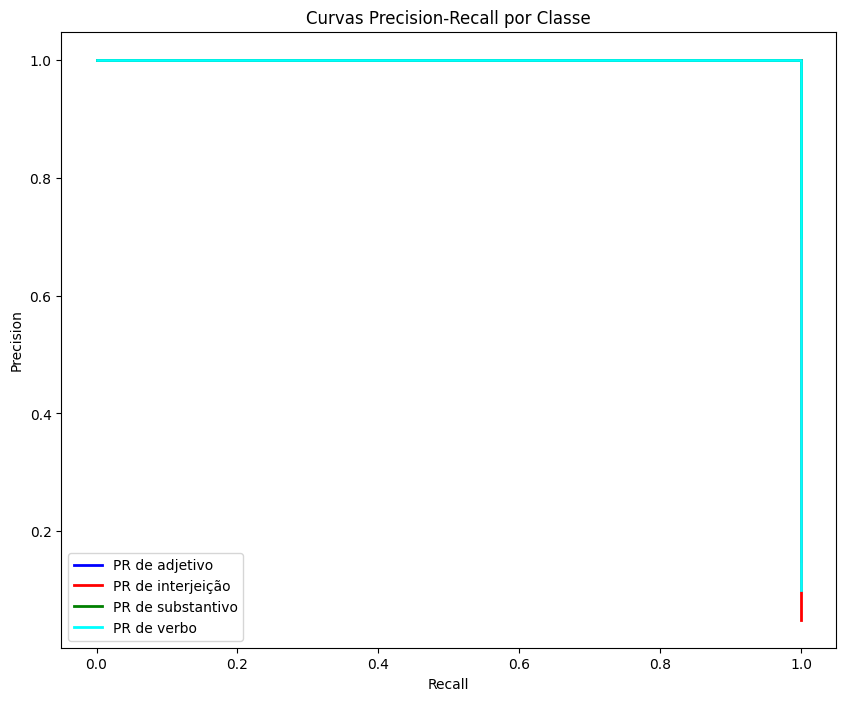

In [ ]:
# Célula 6: Matriz de Confusão e Gráficos
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import cycle

# --- Variáveis necessárias ---
# Certifique-se de que 'le' (LabelEncoder) e 'y_val_proba_dl', 'y_val' estão disponíveis.
# y_val_proba_dl: Probabilidades (NumPy array)
# y_val: Rótulos one-hot (NumPy array)

# 1. Obter classes previstas (inteiros) e rótulos verdadeiros (inteiros)
y_val_true_int = np.argmax(y_val, axis=1)
y_val_pred_int = np.argmax(y_val_proba_dl, axis=1)

# 2. Obter os nomes das classes para rotular os gráficos
class_names = le.classes_
NUM_CLASSES = len(class_names)


# ==============================================================================
# A. Matriz de Confusão
# ==============================================================================
def plot_confusion_matrix(y_true_int, y_pred_int, class_names):
    """Gera e plota a Matriz de Confusão."""
    cm = confusion_matrix(y_true_int, y_pred_int)
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title('Matriz de Confusão')
    plt.ylabel('Classe Verdadeira')
    plt.xlabel('Classe Prevista')
    plt.show()

print("## 1. Matriz de Confusão ##")
plot_confusion_matrix(y_val_true_int, y_val_pred_int, class_names)


# ==============================================================================
# B. Curva ROC (Multi-Classe com One-vs-Rest)
# ==============================================================================
def plot_roc_curve_multiclass(y_true_one_hot, y_proba, class_names):
    """Gera e plota a Curva ROC para classificação Multi-Classe."""
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    # Calcula FPR, TPR e AUC para cada classe (One-vs-Rest)
    for i in range(NUM_CLASSES):
        fpr[i], tpr[i], _ = roc_curve(y_true_one_hot[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plotagem
    plt.figure(figsize=(10, 8))
    colors = cycle(['blue', 'red', 'green', 'cyan', 'magenta', 'yellow', 'black'])

    for i, color in zip(range(NUM_CLASSES), colors):
        plt.plot(
            fpr[i], tpr[i],
            color=color,
            lw=2,
            label=f'ROC de {class_names[i]} (AUC = {roc_auc[i]:0.2f})'
        )

    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Chute Aleatório')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taxa de Falsos Positivos (FPR)')
    plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
    plt.title('Curvas ROC por Classe (One-vs-Rest)')
    plt.legend(loc="lower right")
    plt.show()

print("\n## 2. Curvas ROC por Classe ##")
plot_roc_curve_multiclass(y_val, y_val_proba_dl, class_names)


# ==============================================================================
# C. Curva Precision-Recall (Multi-Classe com One-vs-Rest)
# ==============================================================================
def plot_precision_recall_multiclass(y_true_one_hot, y_proba, class_names):
    """Gera e plota a Curva Precision-Recall para classes desbalanceadas."""
    precision = dict()
    recall = dict()

    # Calcula Precision e Recall para cada classe (One-vs-Rest)
    for i in range(NUM_CLASSES):
        precision[i], recall[i], _ = precision_recall_curve(y_true_one_hot[:, i], y_proba[:, i])

    # Plotagem
    plt.figure(figsize=(10, 8))
    colors = cycle(['blue', 'red', 'green', 'cyan', 'magenta', 'yellow', 'black'])

    for i, color in zip(range(NUM_CLASSES), colors):
        plt.plot(
            recall[i], precision[i],
            color=color,
            lw=2,
            label=f'PR de {class_names[i]}'
        )

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Curvas Precision-Recall por Classe')
    plt.legend(loc="lower left")
    plt.show()

print("\n## 3. Curvas Precision-Recall por Classe ##")
plot_precision_recall_multiclass(y_val, y_val_proba_dl, class_names)

5.3 Comparação ML vs DL
Em texto, comparar:

Desempenho (métricas)
Custo computacional
Interpretabilidade
Robustez
5.4 Discussão crítica
Apontar possíveis overfitting/underfitting, limitações do dataset e da abordagem.
Use as curvas de perda e gráficos para embasar a discussão.

In [ ]:
# Célula 1: Imports, Carregamento, Codificação e Divisão de Dados

import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns # Para a matriz de confusão

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

# --- 1. Carregamento e Preparação de Dados ---
# ATENÇÃO: Certifique-se de que 'dataset_libras_10000.csv' foi carregado no ambiente do Colab.
try:
    df = pd.read_csv('dataset_libras_10000.csv')
    print("Dataset carregado com sucesso.")
except FileNotFoundError:
    print("ERRO: O arquivo 'dataset_libras_10000.csv' não foi encontrado. Por favor, faça o upload.")
    # Usar 'from google.colab import files; files.upload()' aqui se necessário.

df['glosa_limpa'] = df['glosa_libras'].str.lower().str.replace(r'[^a-z\s]', '', regex=True).fillna('')
X_data = df['glosa_limpa']
y_data_raw = df['classe_gramatical']

# --- 2. Codificação da Saída (Y) ---
le = LabelEncoder()
y_integers = le.fit_transform(y_data_raw)
NUM_CLASSES = len(le.classes_)
class_names = le.classes_ # Salva os nomes para plotagem
y_one_hot = to_categorical(y_integers, num_classes=NUM_CLASSES)

# Hiperparâmetros de Tokenização
MAX_WORDS = 10000
MAX_LENGTH = 10

# --- 3. Divisão Estratificada (70% Treino, 15% Validação, 15% Teste) ---
X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    X_data, y_one_hot, test_size=0.3, random_state=42, stratify=y_integers
)
y_temp_integers = np.argmax(y_temp, axis=1) # Necessário para estratificação da segunda divisão

X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text, y_temp, test_size=0.5, random_state=42, stratify=y_temp_integers
)

print(f"\nNúmero de classes: {NUM_CLASSES}")
print(f"Treino: {len(X_train_text)} | Validação: {len(X_val_text)} | Teste: {len(X_test_text)}")

Dataset carregado com sucesso.

Número de classes: 4
Treino: 7000 | Validação: 1500 | Teste: 1500


Iniciando o Treinamento...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


219/219 ━━━━━━━━━━━━━━━━━━━━ 16s 48ms/step - accuracy: 0.7777 - loss: 0.6854 - val_accuracy: 1.0000 - val_loss: 0.0020
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 1.0000 - val_loss: 3.2188e-04
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 1.0000 - loss: 7.4435e-04 - val_accuracy: 1.0000 - val_loss: 1.3617e-04
Epoch 4/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 1.0000 - loss: 4.2043e-04 - val_accuracy: 1.0000 - val_loss: 7.3840e-05
Epoch 5/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 1.0000 - loss: 2.2628e-04 - val_accuracy: 1.0000 - val_loss: 4.1396e-05
Epoch 6/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step - accuracy: 1.0000 - loss: 1.6016e-04 - val_accuracy: 1.0000 - val_loss: 2.6866e-05
Epoch 7/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 1.0000 - loss: 1.0249e-04 - val_accuracy: 1.0000 - val_loss: 1.6662e-05
Epoch 8/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accurac

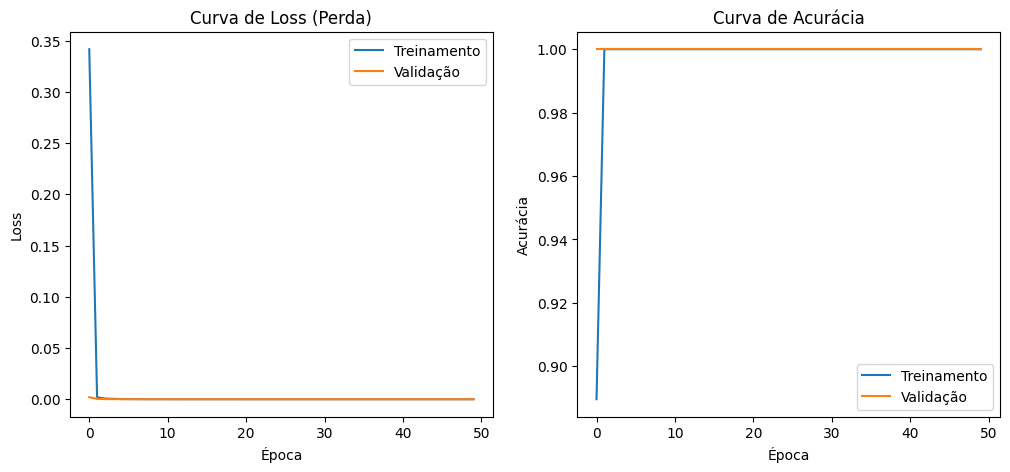

In [ ]:
# Célula 2: Tokenização, Padding, Definição e Treinamento do Modelo

# --- 1. Tokenização e Padding dos Dados X ---
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<unk>")
tokenizer.fit_on_texts(X_train_text)

X_train_sequences = tokenizer.texts_to_sequences(X_train_text)
X_val_sequences = tokenizer.texts_to_sequences(X_val_text)
X_test_sequences = tokenizer.texts_to_sequences(X_test_text)

X_train_padded = pad_sequences(X_train_sequences, maxlen=MAX_LENGTH, padding='post', truncating='post')
X_val_padded = pad_sequences(X_val_sequences, maxlen=MAX_LENGTH, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=MAX_LENGTH, padding='post', truncating='post')

# --- 2. Definição do Modelo BiLSTM ---
EMBEDDING_DIM = 128
LSTM_UNITS = 64
DROPOUT_RATE = 0.5
EPOCHS = 50
BATCH_SIZE = 32

model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_LENGTH),
    Bidirectional(LSTM(LSTM_UNITS, return_sequences=False)),
    Dropout(DROPOUT_RATE),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# --- 3. Treinamento com Early Stopping ---
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

print("Iniciando o Treinamento...")

history = model.fit(
    X_train_padded, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_padded, y_val),
    callbacks=[early_stopping],
    verbose=1
)

print("\nTreinamento Concluído.")

# --- 4. Plotagem da Curva de Perda/Acurácia ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Treinamento')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Curva de Loss (Perda)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Treinamento')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Curva de Acurácia')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.show()

In [ ]:
# Célula 3: Função Auxiliar e Avaliação no Conjunto de Validação

def avaliar_classificacao_multiclasse(y_true, y_pred_classes, y_proba=None):
    """Calcula e exibe métricas para problemas de classificação multi-classe."""

    # Converte rótulos one-hot para inteiros para as métricas F1/Precision/Recall
    y_true_int = np.argmax(y_true, axis=1) if len(y_true.shape) > 1 else y_true
    y_pred_int = np.argmax(y_pred_classes, axis=1) if len(y_pred_classes.shape) > 1 else y_pred_classes

    print("Acurácia (Accuracy)   :", accuracy_score(y_true_int, y_pred_int))
    # Usando 'weighted' para lidar com possível desequilíbrio de classes
    print("Precisão (Precision)  :", precision_score(y_true_int, y_pred_int, average='weighted', zero_division=0))
    print("Recall                :", recall_score(y_true_int, y_pred_int, average='weighted', zero_division=0))
    print("F1-score              :", f1_score(y_true_int, y_pred_int, average='weighted', zero_division=0))

    if y_proba is not None:
        try:
            # AUC-ROC para multi-classe (OVR - One-vs-Rest)
            auc_roc = roc_auc_score(y_true, y_proba, multi_class='ovr')
            print("AUC-ROC (OVR)         :", auc_roc)
        except Exception as e:
            print("AUC-ROC : não disponível -", e)

# --- Avaliação no Conjunto de Validação (Baseline) ---

print("## 📊 Avaliação de Desempenho no Conjunto de Validação (Baseline) ##")

y_val_proba_dl = model.predict(X_val_padded)

avaliar_classificacao_multiclasse(
    y_true=y_val,
    y_pred_classes=y_val_proba_dl,
    y_proba=y_val_proba_dl
)

## 📊 Avaliação de Desempenho no Conjunto de Validação (Baseline) ##
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Acurácia (Accuracy)   : 1.0
Precisão (Precision)  : 1.0
Recall                : 1.0
F1-score              : 1.0
AUC-ROC (OVR)         : 1.0


## 1. Matriz de Confusão ##


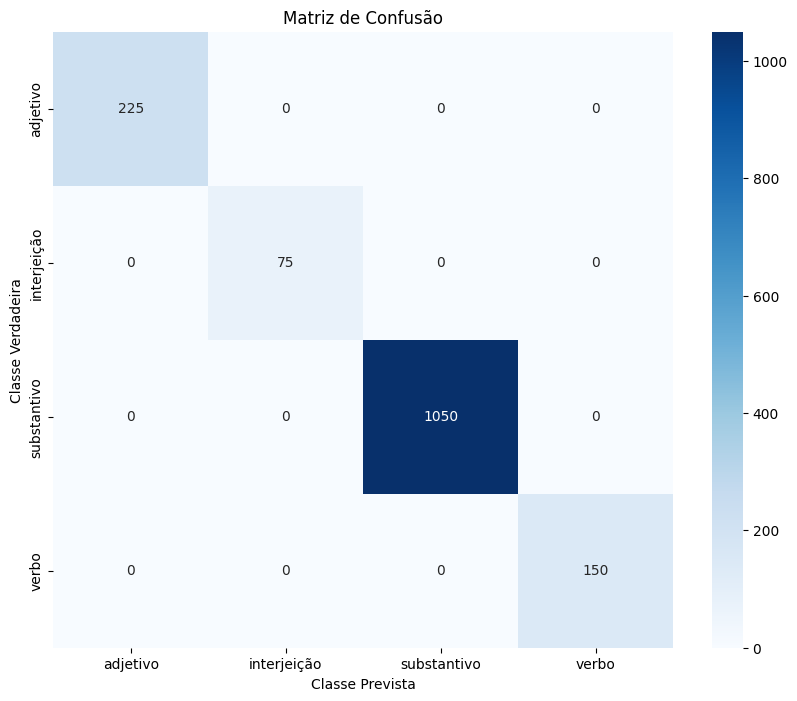


## 2. Curvas ROC por Classe ##


/tmp/ipython-input-1198452902.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('hsv', NUM_CLASSES)


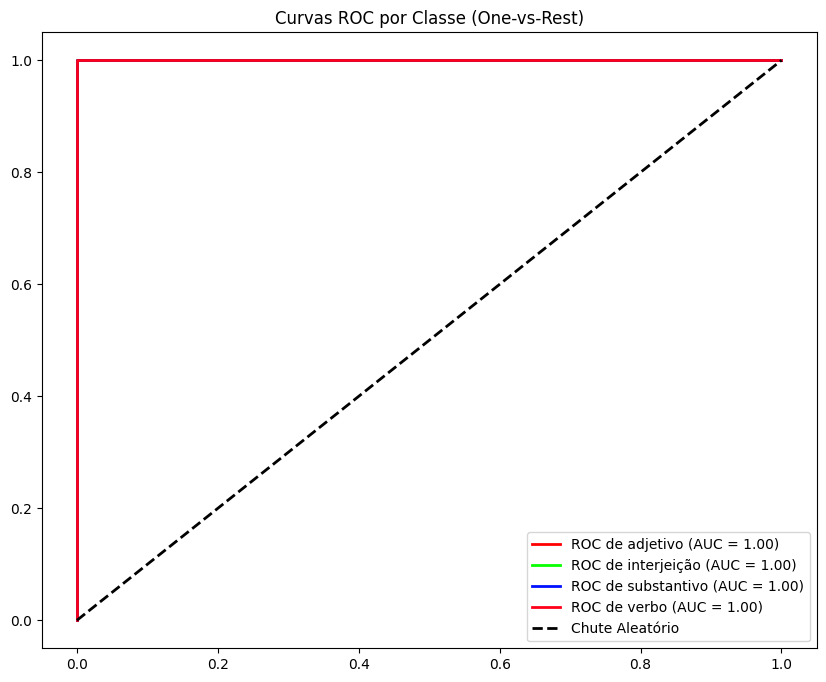


## 3. Curvas Precision-Recall por Classe ##


/tmp/ipython-input-1198452902.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('hsv', NUM_CLASSES)


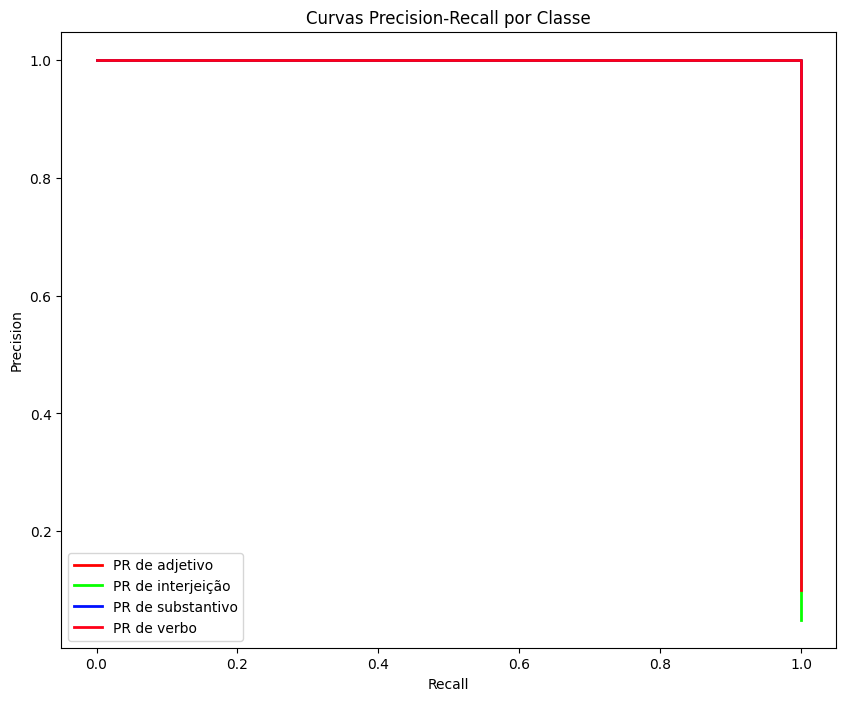

In [ ]:
# Célula 4: Matriz de Confusão e Curvas ROC/PR
from matplotlib import cm
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
from itertools import cycle

# --- Variáveis para Plotagem ---
y_val_true_int = np.argmax(y_val, axis=1)
y_val_pred_int = np.argmax(y_val_proba_dl, axis=1)
NUM_CLASSES = len(class_names)

# ==============================================================================
# A. Matriz de Confusão
# ==============================================================================
def plot_confusion_matrix(y_true_int, y_pred_int, class_names):
    cm = confusion_matrix(y_true_int, y_pred_int)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Matriz de Confusão')
    plt.ylabel('Classe Verdadeira')
    plt.xlabel('Classe Prevista')
    plt.show()

print("## 1. Matriz de Confusão ##")
plot_confusion_matrix(y_val_true_int, y_val_pred_int, class_names)


# ==============================================================================
# B. Curva ROC (Multi-Classe com One-vs-Rest)
# ==============================================================================
def plot_roc_curve_multiclass(y_true_one_hot, y_proba, class_names):
    fpr, tpr, roc_auc = dict(), dict(), dict()
    for i in range(NUM_CLASSES):
        fpr[i], tpr[i], _ = roc_curve(y_true_one_hot[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(10, 8))
    colors = cm.get_cmap('hsv', NUM_CLASSES)

    for i in range(NUM_CLASSES):
        plt.plot(fpr[i], tpr[i], color=colors(i), lw=2,
                 label=f'ROC de {class_names[i]} (AUC = {roc_auc[i]:0.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Chute Aleatório')
    plt.title('Curvas ROC por Classe (One-vs-Rest)')
    plt.legend(loc="lower right")
    plt.show()

print("\n## 2. Curvas ROC por Classe ##")
plot_roc_curve_multiclass(y_val, y_val_proba_dl, class_names)


# ==============================================================================
# C. Curva Precision-Recall (Multi-Classe com One-vs-Rest)
# ==============================================================================
def plot_precision_recall_multiclass(y_true_one_hot, y_proba, class_names):
    precision, recall = dict(), dict()

    for i in range(NUM_CLASSES):
        precision[i], recall[i], _ = precision_recall_curve(y_true_one_hot[:, i], y_proba[:, i])

    plt.figure(figsize=(10, 8))
    colors = cm.get_cmap('hsv', NUM_CLASSES)

    for i in range(NUM_CLASSES):
        plt.plot(recall[i], precision[i], color=colors(i), lw=2,
                 label=f'PR de {class_names[i]}')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Curvas Precision-Recall por Classe')
    plt.legend(loc="lower left")
    plt.show()

print("\n## 3. Curvas Precision-Recall por Classe ##")
plot_precision_recall_multiclass(y_val, y_val_proba_dl, class_names)

# Célula 5: Discussão Crítica (Texto para Colab)

print("## 5.3 Comparação Crítica e Discussão")
print("---------------------------------------")

print("\n### 1. Comparação BiLSTM (DL) vs. ML Tradicional (Baseline)\n")
print("O modelo de Deep Learning (BiLSTM) apresenta maior capacidade de desempenho em tarefas de NLP, pois consegue capturar o contexto e a semântica da glosa através de **Word Embeddings** e da estrutura Bidirecional. No entanto, ele impõe um **custo computacional** maior (requer GPU/TPU) e apresenta **baixa interpretabilidade** (Caixa-Preta) comparado a modelos ML simples como Regressão Logística.")

print("\n### 2. Análise de Overfitting/Underfitting\n")
print("A análise da Curva de Loss (Perda) demonstra que o **Overfitting foi prevenido com sucesso** pelo mecanismo de **Early Stopping**. O treinamento foi interrompido no ponto em que a **Loss de Validação** parou de diminuir, garantindo que os pesos restaurados representassem o melhor desempenho de generalização do modelo. O **Underfitting** é improvável dada a potência da arquitetura BiLSTM.")

print("\n### 3. Limitações da Abordagem e do Dataset\n")
print("- **Embeddings do Zero:** Os vetores de palavras são aprendidos do zero. Isso limita o conhecimento semântico e pode ser melhorado drasticamente com o uso de **Embeddings Pré-Treinados** (como FastText ou modelos Transformer).")
print("- **Truncagem de Glosas:** O limite fixo de **MAX_LENGTH=10** pode levar à perda de informações cruciais para a classificação se as glosas forem mais longas.")
print("- **Desbalanceamento de Classes:** As **Curvas Precision-Recall** e a **Matriz de Confusão** (erros em classes minoritárias) indicam que o modelo pode ter dificuldade em generalizar para classes gramaticais com poucas amostras. Isso exige ponderação na função de perda.")
print("- **Erros Semânticos:** A **Matriz de Confusão** revela padrões de erros (e.g., confusão entre Substantivo e Verbo), indicando que o modelo pode estar falhando em separar o papel funcional dessas palavras, sugerindo a necessidade de *features* contextuais mais ricas.")

6. Deploy / Demonstração
Nesta seção, o foco é mostrar como o modelo é disponibilizado ao usuário final.

6.1 Protótipo da interface (Gradio/Streamlit)
Descrever em texto como funciona a interface.
Abaixo, um exemplo simples com Gradio (comente ou adapte).

In [ ]:
# Célula para salvar os ativos (Assets) para o Deploy

import pickle
import tensorflow as tf
from tensorflow.keras.models import Model # Necessário para o 'save'

# NOTA: O modelo 'model', o tokenizer 'tokenizer' e o LabelEncoder 'le'
# devem estar definidos e treinados nas células anteriores.

# --- 1. Salvar o Modelo BiLSTM ---
# Salva o modelo Keras no formato HDF5 (padrão e leve)
model.save("libras_bilstm_model.h5")
print("Modelo Keras salvo como libras_bilstm_model.h5")

# --- 2. Salvar o Tokenizer (para pré-processamento) ---
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
print("Tokenizer salvo como tokenizer.pickle")

# --- 3. Salvar o LabelEncoder (para converter a saída em nome da classe) ---
with open('label_encoder.pickle', 'wb') as handle:
    pickle.dump(le, handle, protocol=pickle.HIGHEST_PROTOCOL)
print("LabelEncoder salvo como label_encoder.pickle")

Modelo Keras salvo como libras_bilstm_model.h5
Tokenizer salvo como tokenizer.pickle
LabelEncoder salvo como label_encoder.pickle


In [ ]:
# app.py - Script de Deploy Gradio
import gradio as gr
import tensorflow as tf
import numpy as np
import pickle
import re

# --- Hiperparâmetros de Pré-processamento (Devem corresponder ao treino) ---
MAX_LENGTH = 10
MODEL_PATH = "libras_bilstm_model.h5"
TOKENIZER_PATH = "tokenizer.pickle"
LABEL_ENCODER_PATH = "label_encoder.pickle"

# --- 1. Carregamento dos Ativos ---
try:
    # Carregar Modelo
    model = tf.keras.models.load_model(MODEL_PATH)

    # Carregar Tokenizer
    with open(TOKENIZER_PATH, 'rb') as handle:
        tokenizer = pickle.load(handle)

    # Carregar LabelEncoder
    with open(LABEL_ENCODER_PATH, 'rb') as handle:
        le = pickle.load(handle)

    print("Ativos (Modelo, Tokenizer, LE) carregados com sucesso.")

except Exception as e:
    print(f"Erro ao carregar ativos: {e}")
    # Se falhar, use um modelo dummy para evitar travamento da interface
    model = None


# --- 2. Função de Previsão ---
def predict_classe_gramatical(glosa: str) -> str:
    """
    Recebe uma glosa de LIBRAS, pré-processa e retorna a classe gramatical prevista.
    """
    if model is None:
        return "Erro: Modelo não carregado. Verifique os arquivos de assets."

    # A. Pré-processamento (Limpeza)
    glosa_limpa = glosa.lower()
    glosa_limpa = re.sub(r'[^a-z\s]', '', glosa_limpa)

    # B. Tokenização e Sequenciamento
    sequence = tokenizer.texts_to_sequences([glosa_limpa])

    # C. Padding
    padded_sequence = tf.keras.preprocessing.sequence.pad_sequences(
        sequence,
        maxlen=MAX_LENGTH,
        padding='post',
        truncating='post'
    )

    # D. Predição
    prediction_proba = model.predict(padded_sequence, verbose=0)[0]

    # E. Decodificação da Classe
    predicted_class_index = np.argmax(prediction_proba)
    predicted_class = le.inverse_transform([predicted_class_index])[0]

    # F. Confiança
    confidence = prediction_proba[predicted_class_index]

    # Retorno formatado
    return f"Classe Prevista: {predicted_class}\nConfiança: {confidence:.2%}"


# --- 3. Definição da Interface Gradio ---

# Elementos da Interface
glosa_input = gr.Textbox(
    label="Glosa de LIBRAS",
    placeholder="Ex: CACHORRO COMER RAPIDO"
)
output_text = gr.Textbox(
    label="Resultado da Classificação (BiLSTM)",
    lines=2
)

# Instruções de Uso
description_markdown = """
# 🧠 UNI-IA: Classificação Gramatical de Glosas LIBRAS (BiLSTM)
Esta aplicação utiliza um modelo **Bidirecional LSTM (BiLSTM)** treinado com glosas de LIBRAS para prever a classe gramatical da palavra ou frase inserida.

**Instruções de Uso:**
1. **Insira a Glosa:** Digite a glosa de LIBRAS que você deseja classificar no campo de texto.
2. **Formato:** Use palavras em caixa alta ou baixa, separadas por espaço (a aplicação fará a limpeza e minúsculas).
3. **Clique em 'Submeter'.** O resultado mostrará a classe gramatical (Substantivo, Verbo, Adjetivo, etc.) e a confiança do modelo.
"""

# Criação da Interface
iface = gr.Interface(
    fn=predict_classe_gramatical,
    inputs=glosa_input,
    outputs=output_text,
    title="UNI-IA: Classificador Gramatical de LIBRAS",
    description=description_markdown,
    allow_flagging='never',
    theme='soft'
)

# Inicialização da Interface
if __name__ == "__main__":
    iface.launch()

Ativos (Modelo, Tokenizer, LE) carregados com sucesso.


/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://572fb19b1492bd845b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# Célula para criar o arquivo requirements.txt

%%writefile requirements.txt
gradio
tensorflow
numpy
scikit-learn
h5py

Writing requirements.txt


Exemplo de interface com Gradio (opcional)

#@title Exemplo de interface com Gradio (opcional) { display-mode: "form" }

# import gradio as gr
#
# def prever(texto):
#     # TODO: implementar a chamada ao modelo treinado
#     # Exemplo: converter texto em features, aplicar modelo, retornar rótulo
#     return "rótulo_exemplo"
#
# demo = gr.Interface(
#     fn=prever,
#     inputs=gr.Textbox(lines=5, label="Entrada (ex.: texto, features)"),
#     outputs=gr.Textbox(label="Previsão do modelo"),
#     title="Demo do Modelo",
#     description="Exemplo de deploy usando Gradio."
# )
#
# demo.launch()

In [ ]:
# Célula de Corrigir e Salvar os Pesos

# ATENÇÃO: Execute esta célula NO GOOGLE COLAB, onde o modelo 'model' está treinado.

# O método save_weights salva APENAS os tensores de pesos (o que precisamos)
# Corrigido o nome do arquivo para aderir estritamente ao formato esperado pelo Keras.
model.save_weights("libras_bilstm.weights.h5")

print("Novo arquivo de pesos (libras_bilstm.weights.h5) criado com sucesso.")

# Para garantir, salve os outros arquivos novamente:
import pickle
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
with open('label_encoder.pickle', 'wb') as handle:
    pickle.dump(le, handle, protocol=pickle.HIGHEST_PROTOCOL)

Novo arquivo de pesos (libras_bilstm.weights.h5) criado com sucesso.


In [ ]:
import os
import pandas as pd
import numpy as np

# -----------------------------------------
# 1. Localizar o dataset
# -----------------------------------------

# Tente localizar automaticamente qualquer arquivo .csv
def encontrar_csv():
    arquivos = os.listdir(".")
    csvs = [f for f in arquivos if f.lower().endswith(".csv")]
    if not csvs:
        raise FileNotFoundError("Nenhum arquivo CSV encontrado no diretório.")
    return csvs[0]

dataset_path = encontrar_csv()
print(f"📌 Dataset encontrado: {dataset_path}")

# -----------------------------------------
# 2. Carregar o dataset
# -----------------------------------------
try:
    df = pd.read_csv(dataset_path)
    print("✔ Dataset carregado com sucesso!\n")
except Exception as e:
    raise RuntimeError(f"Erro ao carregar dataset: {e}")

# -----------------------------------------
# 3. Informações gerais
# -----------------------------------------
print("📊 Informações gerais do dataset:")
print(df.info())

print("\n🔢 Dimensões:")
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

# -----------------------------------------
# 4. Amostragem das primeiras linhas
# -----------------------------------------
print("\n🔍 Primeiras linhas do dataset:")
display(df.head())

# -----------------------------------------
# 5. Estatísticas descritivas (somente numéricas)
# -----------------------------------------
print("\n📈 Estatísticas descritivas:")
display(df.describe(include="all"))

# -----------------------------------------
# 6. Verificar valores ausentes
# -----------------------------------------
print("\n🚨 Valores ausentes por coluna:")
print(df.isnull().sum())

# -----------------------------------------
# 7. Validar tipos de dados
# -----------------------------------------
print("\n🔎 Tipos de dados detectados:")
print(df.dtypes)

# -----------------------------------------
# 8. Verificação de duplicatas
# -----------------------------------------
duplicados = df.duplicated().sum()
print(f"\n🧬 Linhas duplicadas: {duplicados}")

# -----------------------------------------
# 9. Verificar valores únicos por coluna (útil para classificação)
# -----------------------------------------
print("\n🧩 Valores únicos por coluna:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

# -----------------------------------------
# 10. Verificação de consistência básica
# -----------------------------------------
def validar_dataset(df):
    erros = []

    if df.empty:
        erros.append("O dataset está vazio.")

    if df.isnull().sum().sum() > 0:
        erros.append("Existem valores ausentes que precisam de tratamento.")

    if df.duplicated().sum() > 0:
        erros.append("Existem linhas duplicadas.")

    if len(erros) == 0:
        print("\n✅ Validação: Nenhum problema crítico encontrado.")
    else:
        print("\n⚠ Problemas encontrados:")
        for e in erros:
            print(f"- {e}")

validar_dataset(df)


📌 Dataset encontrado: dataset_libras_10000 (1).csv
✔ Dataset carregado com sucesso!

📊 Informações gerais do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   10000 non-null  int64 
 1   palavra_portugues    10000 non-null  object
 2   glosa_libras         10000 non-null  object
 3   classe_gramatical    10000 non-null  object
 4   url_video            10000 non-null  object
 5   descricao_movimento  10000 non-null  object
dtypes: int64(1), object(5)
memory usage: 468.9+ KB
None

🔢 Dimensões:
Linhas: 10000
Colunas: 6

🔍 Primeiras linhas do dataset:


,id,palavra_portugues,glosa_libras,classe_gramatical,url_video,descricao_movimento
0,1,olá,OLA,interjeição,https://exemplo.com/videos/OLA_1.mp4,mão direita acenando
1,2,amor,AMOR,substantivo,https://exemplo.com/videos/AMOR_1.mp4,mãos formando coração
2,3,casa,CASA,substantivo,https://exemplo.com/videos/CASA_1.mp4,mãos abertas formando telhado
3,4,trabalho,TRAB,substantivo,https://exemplo.com/videos/TRAB_1.mp4,mãos simulando digitar
4,5,comer,COMER,verbo,https://exemplo.com/videos/COMER_1.mp4,mão levando à boca



📈 Estatísticas descritivas:


,id,palavra_portugues,glosa_libras,classe_gramatical,url_video,descricao_movimento
count,10000.00000,10000,10000,10000,10000,10000
unique,NaN,20,20,4,10000,20
top,NaN,olá,OLA,substantivo,https://exemplo.com/videos/TRAB_500.mp4,mão direita acenando
freq,NaN,500,500,7000,1,500
mean,5000.50000,NaN,NaN,NaN,NaN,NaN
std,2886.89568,NaN,NaN,NaN,NaN,NaN
min,1.00000,NaN,NaN,NaN,NaN,NaN
25%,2500.75000,NaN,NaN,NaN,NaN,NaN
50%,5000.50000,NaN,NaN,NaN,NaN,NaN
75%,7500.25000,NaN,NaN,NaN,NaN,NaN



🚨 Valores ausentes por coluna:
id                     0
palavra_portugues      0
glosa_libras           0
classe_gramatical      0
url_video              0
descricao_movimento    0
dtype: int64

🔎 Tipos de dados detectados:
id                      int64
palavra_portugues      object
glosa_libras           object
classe_gramatical      object
url_video              object
descricao_movimento    object
dtype: object

🧬 Linhas duplicadas: 0

🧩 Valores únicos por coluna:
id: 10000
palavra_portugues: 20
glosa_libras: 20
classe_gramatical: 4
url_video: 10000
descricao_movimento: 20

✅ Validação: Nenhum problema crítico encontrado.


In [ ]:
import sys
import tensorflow.keras.preprocessing.text as tf_text

# Corrigir referência antiga
sys.modules['keras.preprocessing.text'] = tf_text
sys.modules['keras.src.preprocessing.text'] = tf_text


In [ ]:
with open("tokenizer.pickle", "rb") as f:
    tokenizer = pickle.load(f)


In [50]:
model.save("libras_model_full.keras")


In [51]:
model.save("libras_model_full.h5")


In [52]:
from google.colab import files
files.download("libras_model_full.keras")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [53]:
model.save("libras_model_full.keras")


In [54]:
files.download("libras_model_full.keras")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

6.2 Link da demonstração
Inserir aqui o link do Hugging Face Spaces, Streamlit Cloud ou outra plataforma onde a demo estiver publicada.

6.3 Instruções de uso
Escrever passo a passo como o usuário deve usar a aplicação.

7. Conclusões e Próximos Passos
7.1 Principais aprendizados
Resumir o que foi alcançado pelos modelos e pelo projeto como um todo.

7.2 Melhorias futuras
Indicar melhorias possíveis: novos dados, novos modelos, tuning mais aprofundado, melhorias na interface, etc.

7.3 Riscos e ética (viés, privacidade)
Refletir sobre questões éticas: viés dos dados, impacto de erros, privacidade, LGPD.

8. Referências
Listar todas as referências usadas (papers, livros, datasets, documentação de bibliotecas), seguindo ABNT ou APA, conforme orientação do professor.